# Practical Project: USGS Earthquakes Pipeline

# Module 2 - Data Acquisition and Cleaning

In this project we will build a small but real **scientific data pipeline** using the **USGS Earthquake Catalog API**.  

### What will be produced:
Artifacts (all under a project folder):
* `data/raw/`: raw API snapshots + metadata (query params, timestamps)
* `data/staged/`: parsed/normalized table (deduped, typed)
* `data/warehouse/`: curated table (Parquet; optionally partitioned by day)
* `data/reference/validation_report.json`: contracts + anomaly rates + canaries
* `data/reference/pipeline_runs/`: run logs for reproducibility

## 0 - Setup

Project will be created in the path relative to this notebook  

`/work/m2_project/`

In [1]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime, timedelta, timezone
import json
import hashlib
import math

import numpy as np
import pandas as pd

from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

WORK_DIR = Path("work")
PROJECT_DIR = WORK_DIR / "m2_project"

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
STAGED_DIR = DATA_DIR / "staged"
WH_DIR = DATA_DIR / "warehouse"
REF_DIR = DATA_DIR / "reference"
RUN_DIR = REF_DIR / "pipeline_runs"

for p in [RAW_DIR, STAGED_DIR, WH_DIR, REF_DIR, RUN_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Raw:", RAW_DIR)
print("Staged:", STAGED_DIR)
print("Warehouse:", WH_DIR)
print("Reference:", REF_DIR)
print("Runs:", RUN_DIR)

Project: work/m2_project
Raw: work/m2_project/data/raw
Staged: work/m2_project/data/staged
Warehouse: work/m2_project/data/warehouse
Reference: work/m2_project/data/reference
Runs: work/m2_project/data/reference/pipeline_runs


### Helper Utilities  

These helpers keep the notebook focused on pipeline thinking rather than boilerplate

In [2]:
class PipelineError(RuntimeError):
    pass

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def sha16(x: str) -> str:
    return hashlib.sha256(x.encode("utf-8")).hexdigest()[:16]

def write_json(path: Path, obj: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, default=str))

def read_json(path: Path) -> dict:
    return json.loads(path.read_text())

def require_columns(df: pd.DataFrame, cols: list[str], context: str) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise PipelineError(f"[{context}] Missing required columns: {missing}")

def require_unique(df: pd.DataFrame, key: str, context: str) -> None:
    if key not in df.columns:
        raise PipelineError(f"[{context}] Missing key column '{key}'")
    dupes = int(df[key].duplicated().sum())
    if dupes:
        raise PipelineError(f"[{context}] Key '{key}' has {dupes} duplicates")

print("Helpers ready.")

Helpers ready.


## 1 - Ingest: Pull Earthquakes From USGS API (Paginated)

We will use the USGS **event** endpoint (GeoJSON):
* base `https://earthquak.usgs.gov/fdsnws/event/1/query`
* params `format=geojson`, `starttime`, `endtime`, `minmagnitude`, plus pagination (`limit, offset`)

### Choose a query window
Set:
* `DAYS_BACK` = 30
* `MIN_MAG` = 2.5

Then build `starttime` and `endtime` in **UTC** as ISO dates

**Note:** The API likes `YYYY-MM-DD` strings

In [3]:
# Set query window
DAYS_BACK = 30
MIN_MAG = 2.5

# compute starttime/endtime as YYYY-MM-DD (UTC-based)
endtime_dt = datetime.now(timezone.utc)
starttime_dt = endtime_dt - timedelta(days=DAYS_BACK)

starttime = starttime_dt.strftime('%Y-%m-%d')
endtime = endtime_dt.strftime('%Y-%m-%d')

print(f"starttime: {starttime}")
print(f"endtime: {endtime}")
print(f"minmagnitude: {MIN_MAG}")

starttime: 2026-01-04
endtime: 2026-02-03
minmagnitude: 2.5


### Implement pagination

Write `fetch_usgs_pages(...)` that:
* requests pages using `limit` and `offset`
* stops when a page returns fewer than `limit` features
* returns a list of page dictionaries

**Constraints:**  
* Use a small `limit` while testing (e.g., 200) to see pagination work.
* Add a polite `sleep` if wanted, but keep it simple

**Note:**
* `obj["features"]` = list of events
* `obj["metadata"]["count"]` = count for the query (not always equal to returned features)

In [4]:
import time
import requests

USGS_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"

def fetch_usgs_pages(starttime: str, endtime: str, minmag: float, limit: int=200, max_pages: int=50) -> list[dict]:
    pages = []
    offset = 1  # USGS uses 1-based offsets
    for page_i in range(max_pages):
        params = {
            "format": "geojson",
            "starttime": starttime,
            "endtime": endtime,
            "minmagnitude": minmag,
            "limit": limit,
            "offset": offset,
            "orderby": "time",
        }

        # Request the page, check the status, parse JSON
        print(f"Fetching page {page_i + 1} (offset={offset})...", end=" ")
        response = requests.get(USGS_URL, params=params)

        # Check for HTTP erros
        response.raise_for_status()

        data = response.json()
        features = data.get("features", [])
        total_count = data.get("metadata", {}).get("count", 0)
        print(f"got {len(features)} events (total in query: {total_count})")

        # Quick stop if there are no results
        if not features:
            print("No more results, stopping")
            break

        pages.append(data)

        # Stop if we get fewer results than the limit (last page)
        if len(features) < limit:
            print("Partial page received, stopping")
            break

        # Increment offset for next page
        offset += limit

        # Short polite break for API
        time.sleep(0.5)

    return pages

print("Fetcher ready.")
        

Fetcher ready.


### Fetch data and write a raw snapshot

Run the fetch and write:  
* raw pages: `data/raw/usgs_pages_<runid>.jsonl`
* raw_metadata: `data/raw/usgs_meta_<runid>.json`

**Note:**  
`.jsonl` means "JSON lines": one JSON object per line

In [7]:
from pprint import pprint

# Fetch data and write raw snapshot

# Compute run_id
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_utc")

# Fetch pages
pages = fetch_usgs_pages(starttime, endtime, MIN_MAG, limit=200)
print(f"\nFetched {len(pages)} pages")

# Count total events
total_events = sum(len(p['features']) for p in pages)
print(f"Total events: {total_events}")

# Write raw pages as JSONL (one JSON object per line)
pages_path = RAW_DIR / f"usgs_pages_{RUN_ID}.jsonl"
pages_path.parent.mkdir(parents=True, exist_ok=True)

with pages_path.open('w') as f:
    for page in pages:
        f.write(json.dumps(page) + '\n')

print(f"Wrote pages: {pages_path}")

# Write metadata
metadata = {
    "run_id": RUN_ID,
    "generated_at_utc": utc_now_iso(),
    "query": {
        "starttime": starttime,
        "endtime": endtime,
        "minmagnitude": MIN_MAG,
    },
    "n_pages": len(pages),
    "n_features_total": total_events,
    "source": "USGS Earthquake Catalog (GeoJSON)",
    "endpoint": USGS_URL,
}

meta_path = RAW_DIR / f"usgs_meta_{RUN_ID}.json"
write_json(meta_path, metadata)
print(f"Wrote metadata: {meta_path}")


# Pretty print the metadata
print("\nMetadata:")
pprint(metadata, sort_dicts=False)
      

Fetching page 1 (offset=1)... got 200 events (total in query: 200)
Fetching page 2 (offset=201)... got 200 events (total in query: 200)
Fetching page 3 (offset=401)... got 200 events (total in query: 200)
Fetching page 4 (offset=601)... got 200 events (total in query: 200)
Fetching page 5 (offset=801)... got 200 events (total in query: 200)
Fetching page 6 (offset=1001)... got 200 events (total in query: 200)
Fetching page 7 (offset=1201)... got 200 events (total in query: 200)
Fetching page 8 (offset=1401)... got 190 events (total in query: 190)
Partial page received, stopping

Fetched 8 pages
Total events: 1590
Wrote pages: work/m2_project/data/raw/usgs_pages_20260203_171853_utc.jsonl
Wrote metadata: work/m2_project/data/raw/usgs_meta_20260203_171853_utc.json

Metadata:
{'run_id': '20260203_171853_utc',
 'generated_at_utc': '2026-02-03T17:18:58.340696+00:00',
 'query': {'starttime': '2026-01-04',
           'endtime': '2026-02-03',
           'minmagnitude': 2.5},
 'n_pages': 8,
 'n_

## 2 - Stage: Normalize GeoJSON &rarr; Table

USGS GeoJSON structure:
* `feature["id"]` is a stable event id
* `feature["properties"]` contains magnitude, place, time, etc.
* `feature["geometry"]["coordinates"]`is`[longitude, latitude, depth_km]`

### Flatten features into a DataFrame  

Implement `features_to_df(pages)` that returns one DataFrame with one row per event.

**Note:**  
`pd.json_normalize(features)` will help

In [8]:
# Create a DataFrame with one row per event
def features_to_df(pages: list[dict]) -> pd.DataFrame:
    # 1. Extract all features from all pages
    all_features = []
    for page in pages:
        all_features.extend(page.get("features", []))

    # 2. Use pd.json_normalize to flatten nested structures, automatically
    df = pd.json_normalize(all_features)

    # 3. Extract coordinates into separate columns
    # geometry.coordintates is [longitude, latitude, depth km]
    df['longitude'] = df['geometry.coordinates'].apply(lambda x: x[0] if x else None)
    df['latitude'] = df['geometry.coordinates'].apply(lambda x: x[1] if x else None)
    df['depth_km'] = df['geometry.coordinates'].apply(lambda x: x[2] if x else None)

    # 4. Clean up column names (remove properties prefix)
    df.columns = df.columns.str.replace('properties.', '', regex=False)

    # 5. Drop the original nested column (geometry.coordinates)
    df = df.drop(columns=['geometry.coordinates'], errors='ignore')

    return df

print("flattening function ready")

flattening function ready


In [9]:
df_raw = features_to_df(pages)
print(f"Raw flattened shape: {df_raw.shape}")
display(df_raw.head(5))

Raw flattened shape: (1590, 32)


,type,id,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,geometry.type,longitude,latitude,depth_km
0,Feature,us6000s620,4.10,"16 km E of Calingasta, Argentina",1770075292434,1770080742040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,None,reviewed,0,259,us,6000s620,",us6000s620,",",us,",",origin,phase-data,",27,1.3220,0.79,89.0,mb,earthquake,"M 4.1 - 16 km E of Calingasta, Argentina",Point,-69.251700,-31.317600,162.179
1,Feature,uw62216847,2.80,"5 km ESE of Benton City, Washington",1770075173110,1770096410010,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,None,reviewed,0,121,uw,62216847,",uw62216847,",",uw,",",origin,phase-data,",14,0.1610,0.28,202.0,ml,explosion,"M 2.8 Explosion - 5 km ESE of Benton City, Was...",Point,-119.422000,46.234500,-0.240
2,Feature,nc75306276,2.94,"5 km SE of San Ramon, CA",1770073598570,1770101775717,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,10.0,3.3,NaN,None,automatic,0,136,nc,75306276,",nc75306276,us6000s61u,",",nc,us,",",dyfi,focal-mechanism,nearby-cities,origin,pha...",64,0.1036,0.10,37.0,ml,earthquake,"M 2.9 - 5 km SE of San Ramon, CA",Point,-121.935837,37.754501,7.370
3,Feature,nc75306271,3.00,"4 km ESE of San Ramon, CA",1770073458430,1770134850183,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,25.0,4.1,NaN,None,reviewed,0,149,nc,75306271,",nc75306271,us6000s61t,",",nc,us,",",dyfi,focal-mechanism,nearby-cities,origin,pha...",74,0.1056,0.10,39.0,ml,earthquake,"M 3.0 - 4 km ESE of San Ramon, CA",Point,-121.935333,37.763332,8.380
4,Feature,nc75306256,3.14,"4 km ESE of San Ramon, CA",1770072973340,1770098210597,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,97.0,3.4,NaN,None,reviewed,0,185,nc,75306256,",nc75306256,us6000s61s,",",nc,us,",",dyfi,focal-mechanism,nearby-cities,origin,pha...",80,0.1033,0.12,26.0,ml,earthquake,"M 3.1 - 4 km ESE of San Ramon, CA",Point,-121.937164,37.765167,7.820


### Parse types and extract coordinates  

Create a staged table with columns:  
* `event_id`: string
* `time_utc`: datetime
* `updated_utc`: datetime
* `mag`: float
* `place`: string
* `longitude`: float
* `latitude`: float
* `depth_km`: float
* `tsunami`: int
* `status`: string

USGS times are often **milliseconds since epoch**  

**Note:** `pd.to_datetime(ms, unit="ms", utc=True)  

Also:
* Deduplicate by `event_id` (keep first)
* Normalize missing-like strings

In [10]:
# Build staged dataframe
def staged_dataframe(data: pd.DataFrame) -> pd.DataFrame:
    MISSING_TOKENS = {"", "nan", "None", "UNKNOWN", "Unknown", "N/A", "NA", "NULL", "null"}
    
    staged = pd.DataFrame()

    # 1. event_id: basic identification - rename and ensure string type
    staged['event_id'] = data['id'].astype(str)

    # 2. time_utc: parse timestamps from unix milliseconds to datetime
    staged['time_utc'] = pd.to_datetime(data['time'], unit='ms', utc=True)

    # 3. updated_utc: parse timestamps from unix milliseconds to datetime
    staged['updated_utc'] = pd.to_datetime(data['updated'], unit='ms', utc=True)

    # 4. mag: handle missing values and convert to float (coerce = NaN)
    staged['mag'] = pd.to_numeric(data['mag'], errors='coerce')

    # 5. place: location description - ensure string type
    staged['place'] = data['place'].astype(str)

    # 6. coordinates (longitude, latitude, depth_km): already extracted, just add and handle missing values
    staged['longitude'] = pd.to_numeric(data['longitude'], errors='coerce')
    staged['latitude'] = pd.to_numeric(data['latitude'], errors='coerce')
    staged['depth_km'] = pd.to_numeric(data['depth_km'], errors='coerce')

    # 7. tsunami: flag to indicate a tsunami - convert to int, fill missing with 0
    staged['tsunami'] = pd.to_numeric(data['tsunami'], errors='coerce').fillna(0).astype(int)

    # 8. status: review status - convert to string
    staged['status'] = data['status'].astype(str)

    # 9. Normalize missing-like strings to NaN for all string columns
    for col in staged.columns:
        if staged[col].dtype == 'object':  # string columns have dtype 'object'
            staged[col] = staged[col].replace(MISSING_TOKENS, np.nan)

    # 10. Delete duplicate entries by event_id. Keep the first entry
    entries_prior = len(staged)
    staged = staged.sort_values('time_utc', ascending=False)
    staged = staged.drop_duplicates(subset=['event_id'], keep='first')
    entries_after = len(staged)
    print(f"Deduped: {entries_prior} -> {entries_after}")

    return staged

print("function to create staged DataFrame ready")

function to create staged DataFrame ready


In [11]:
df_staged = staged_dataframe(df_raw)
print(f"Staged shape: {df_staged.shape}")
display(df_staged.head(5))

Deduped: 1590 -> 1590
Staged shape: (1590, 10)


,event_id,time_utc,updated_utc,mag,place,longitude,latitude,depth_km,tsunami,status
0,us6000s620,2026-02-02 23:34:52.434000+00:00,2026-02-03 01:05:42.040000+00:00,4.10,"16 km E of Calingasta, Argentina",-69.251700,-31.317600,162.179,0,reviewed
1,uw62216847,2026-02-02 23:32:53.110000+00:00,2026-02-03 05:26:50.010000+00:00,2.80,"5 km ESE of Benton City, Washington",-119.422000,46.234500,-0.240,0,reviewed
2,nc75306276,2026-02-02 23:06:38.570000+00:00,2026-02-03 06:56:15.717000+00:00,2.94,"5 km SE of San Ramon, CA",-121.935837,37.754501,7.370,0,automatic
3,nc75306271,2026-02-02 23:04:18.430000+00:00,2026-02-03 16:07:30.183000+00:00,3.00,"4 km ESE of San Ramon, CA",-121.935333,37.763332,8.380,0,reviewed
4,nc75306256,2026-02-02 22:56:13.340000+00:00,2026-02-03 05:56:50.597000+00:00,3.14,"4 km ESE of San Ramon, CA",-121.937164,37.765167,7.820,0,reviewed


### Write staged output  

Write:  
* `data/staged/usgs_earthquakes_staged_<runid>.parquet`
* `data/staged/usgs_staged_meta_<runid>.json`

In [51]:
# Determine file paths
staged_parquet_path = STAGED_DIR / f"usgs_earthquakes_staged_{RUN_ID}.parquet"
staged_metadata_path = STAGED_DIR / f"usgs_staged_meta_{RUN_ID}.json"

# Create staged metadata
staged_metadata = {
    "run_id": RUN_ID,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "pipeline_stage": "staged",

    "input": {
        "source": "USGS Earthquake API",
        "api_endpoint": USGS_URL,
        "raw_records_fetched": len(df_raw),
    },

    "output": {
        "parquet_file": staged_parquet_path.name,
        "parquet_path": str(staged_parquet_path),
        "rows": len(df_staged),
        "columns": len(df_staged.columns),
        "column_list": df_staged.columns.tolist(),
    },

    "schema": {
        col: str(dtype) for col, dtype in df_staged.dtypes.items()
    },
    
}

# Write outputs
df_staged.to_parquet(staged_parquet_path, index=False)
print(f"Wrote: {staged_parquet_path}")
with open(staged_metadata_path, 'w') as f:
    json.dump(staged_metadata, f, indent=2)
print(f"Wrote: {staged_metadata_path}")


Wrote: work/m2_project/data/staged/usgs_earthquakes_staged_20260203_171853_utc.parquet
Wrote: work/m2_project/data/staged/usgs_staged_meta_20260203_171853_utc.json


## 3 - Curate: Build Analysis-Ready Features

Create a curated table with:  
* time features: `event_day`, `event_hour`, `dayofweek`, `is_weekend`
* magnitude bins and flags
* a lightweight region extraction from place

### Feature Construction  

Implement:
* `event_day`: date(UTC)
* `event_hour`: hour(UTC)
* `mag_bin`: (example bins): <2.5, 2.5-4.5, 4.5-6.0, 6.0+
* `is_major`: mag >= 6.0
* `region`: parsed from `place`:
   * if `place` contains `" of "`, take the substring after the last `" of "`
   * otherwise use the full `place`

**Note:**
`str.rsplit(" of", 1)`

In [13]:
def parse_region(place: str) -> str:
    if pd.isna(place):
        return None

    if " of " in place:
        return place.rsplit(" of ", 1)[1]
    else:
        return place

print("Region parser function ready")

Region parser function ready


In [16]:
def curated_dataframe(data: pd.DataFrame) -> pd.DataFrame:
    # Build a curated DataFrame
    df_curated = data.copy()
    
    # 1. Extract date (removes time component)
    df_curated['event_day'] = df_curated['time_utc'].dt.date
    
    # 2. Extract hour
    df_curated['event_hour'] = df_curated['time_utc'].dt.hour
    
    # 3. Extract day of week
    df_curated['dayofweek'] = df_curated['time_utc'].dt.dayofweek
    
    # 4. Weekend flag
    df_curated['is_weekend'] = df_curated['dayofweek'].isin([5, 6]).astype(int)
    
    # 5. Magnitude bins
    # define
    bins = [-float('inf'), 2.5, 4.5, 6.0, float('inf')]
    labels = ['<2.5', '2.5-4.5', '4.5-6.0', '6.0+']
    # add
    df_curated['mag_bin'] = pd.cut(df_curated['mag'], bins=bins, labels=labels)
    
    # 6. Flag for major earthquakes (>6.0)
    df_curated['is_major'] = (df_curated['mag'] >- 6.0).astype(int)
    
    # 7. Parse region
    df_curated['region'] = df_curated['place'].apply(parse_region)

    return df_curated

print("curated dataframe function ready")

curated dataframe function ready


In [17]:
df_curated = curated_dataframe(df_staged)
print(f"Curated shape: {df_curated.shape}")
display(df_curated.head(5))

Curated shape: (1590, 17)


,event_id,time_utc,updated_utc,mag,place,longitude,latitude,depth_km,tsunami,status,event_day,event_hour,dayofweek,is_weekend,mag_bin,is_major,region
0,us6000s620,2026-02-02 23:34:52.434000+00:00,2026-02-03 01:05:42.040000+00:00,4.10,"16 km E of Calingasta, Argentina",-69.251700,-31.317600,162.179,0,reviewed,2026-02-02,23,0,0,2.5-4.5,1,"Calingasta, Argentina"
1,uw62216847,2026-02-02 23:32:53.110000+00:00,2026-02-03 05:26:50.010000+00:00,2.80,"5 km ESE of Benton City, Washington",-119.422000,46.234500,-0.240,0,reviewed,2026-02-02,23,0,0,2.5-4.5,1,"Benton City, Washington"
2,nc75306276,2026-02-02 23:06:38.570000+00:00,2026-02-03 06:56:15.717000+00:00,2.94,"5 km SE of San Ramon, CA",-121.935837,37.754501,7.370,0,automatic,2026-02-02,23,0,0,2.5-4.5,1,"San Ramon, CA"
3,nc75306271,2026-02-02 23:04:18.430000+00:00,2026-02-03 16:07:30.183000+00:00,3.00,"4 km ESE of San Ramon, CA",-121.935333,37.763332,8.380,0,reviewed,2026-02-02,23,0,0,2.5-4.5,1,"San Ramon, CA"
4,nc75306256,2026-02-02 22:56:13.340000+00:00,2026-02-03 05:56:50.597000+00:00,3.14,"4 km ESE of San Ramon, CA",-121.937164,37.765167,7.820,0,reviewed,2026-02-02,22,0,0,2.5-4.5,1,"San Ramon, CA"


### Choose curated columns and write Parquet  

Write:  
* `data/warehouse/usgs_earthquakes_curated_<runid>.parquet`
* partition by `event_day` under `data/warehouse/partitions/event_day=YYYY-MM-DD/earthquakes.parquet`


In [24]:
# Select curated columns
curated_columns = [
    # Identification
    "event_id",

    # Time features
    "time_utc",
    "event_day",
    "event_hour",
    "dayofweek",
    "is_weekend",

    # Location
    "longitude",
    "latitude",
    "depth_km",
    "place",
    "region",

    # Magnitude
    "mag",
    "mag_bin",
    "is_major",

    # Impact/flags
    "tsunami",
    "status",
]

# Create final curated datafram with selected columns and write
df_curated_final = df_curated[curated_columns].copy()
curated_parquet_path = WH_DIR / f"usgs_earthquakes_curated_{RUN_ID}.parquet"
df_curated_final.to_parquet(curated_parquet_path, index=False)
print(f"Wrote curated parquet: {curated_parquet_path.name}")

# Write partitioned parquet
PART_DIR = WH_DIR / "partitions"
PART_DIR.mkdir(parents=True, exist_ok=True)
partition_count = 0
for day, day_data in df_curated_final.groupby('event_day'):
    day_str = str(day)
    partition_dir = PART_DIR / f"event_day={day_str}"
    partition_dir.mkdir(parents=True, exist_ok=True)

    partition_path = partition_dir / "earthquakes.parquet"
    day_data.to_parquet(partition_path, index=False)
    partition_count += 1

print(f"Wrote {partition_count} partitions to {PART_DIR.relative_to(WORK_DIR)}")



Wrote curated parquet: usgs_earthquakes_curated_20260203_171853_utc.parquet
Wrote 30 partitions to m2_project/data/warehouse/partitions


## 4 - Validate: Contracts + Anomalies + Canaries

### Define Contracts

In [26]:
# Determine required columns
REQUIRED_COLS = {
    "event_id",
    "time_utc",
    "mag",
    "latitude",
    "longitude",
    "depth_km",
}

# Determine valid ranges
MAG_MIN = -1.0
MAG_MAX = 10.0
DEPTH_MIN = -10.0
DEPTH_MAX = 700.0

print("Contracts defined:")
print(f"  Required cols: {REQUIRED_COLS}")
print(f"  Magnitude range: ({MAG_MIN}, {MAG_MAX})")
print(f"  Depth range (km): ({DEPTH_MIN}, {DEPTH_MAX})")

Contracts defined:
  Required cols: {'longitude', 'time_utc', 'depth_km', 'mag', 'event_id', 'latitude'}
  Magnitude range: (-1.0, 10.0)
  Depth range (km): (-10.0, 700.0)


### Implement validation checks

In [31]:
def validate_contracts(data: pd.DataFrame) -> dict:
    results = {"passed": True, "checks": []}

    def record_check(name: str, passed: bool, details: str):
        results["checks"].append({
            "name": name,
            "passed": passed,
            "details": details
        })
        if not passed:
            results["passed"] = False

    # 1. Required columns exist
    missing_cols = set(REQUIRED_COLS) - set(data.columns)
    record_check(
        "required_columns",
        len(missing_cols) == 0,
        f"Missing columns: {list(missing_cols)}" if missing_cols else "All required columns present"
    )

    # 2. Non-empty dataset
    record_check(
        "non_empty",
        len(data) > 0,
        f"Dataset has {len(data)} rows"
    )

    # 3. event_id unique
    duplicate_count = data['event_id'].duplicated().sum()
    record_check(
        "event_id_unique",
        duplicate_count == 0,
        f"Found {duplicate_count} duplicate event_ids" if duplicate_count > 0 else "All event_ids unique"
    )

    # 4. Latitude range
    invalid_lat = (~data['latitude'].between(-90, 90)).sum()
    record_check(
        "latitude_range",
        invalid_lat == 0,
        f"Found {invalid_lat} invalid latitudes" if invalid_lat > 0 else "All latitudes in valid range [-90, 90]"
    )

    # 5. Longitude range
    invalid_lon = (~data['longitude'].between(-180, 180)).sum()
    record_check(
        "longitude_range",
        invalid_lon == 0,
        f"Found {invalid_lon} invalid longitudes" if invalid_lon > 0 else "All longitudes in valid range [-180, 180]"
    )

    # 6. Magnitude range
    invalid_mag = (~data['mag'].between(MAG_MIN, MAG_MAX)).sum()
    record_check(
        "magnitude_range",
        invalid_mag == 0,
        f"Found {invalid_mag} magnitudes outside [{MAG_MIN}, {MAG_MAX}]" if invalid_mag > 0 else f"All magnitudes in valid range [{MAG_MIN}, {MAG_MAX}]"
    )

    # 7. Depth Range
    invalid_depth = (~data['depth_km'].between(DEPTH_MIN, DEPTH_MAX)).sum()
    record_check(
        "depth_range",
        invalid_depth == 0,
        f"Found {invalid_depth} depths outside [{DEPTH_MIN}, {DEPTH_MAX}] km" if invalid_depth > 0 else f"All depths in valid range [{DEPTH_MIN}, {DEPTH_MAX}] km"
    )

    # 8. No future events
    now = pd.Timestamp.now(tz='UTC')
    future_events = (data['time_utc'] > now).sum()
    record_check(
        "no_future_events",
        future_events == 0,
        f"Found {future_events} events in the future" if future_events > 0 else "No future events detected"
    )

    return results

print("Validation function ready")

Validation function ready


In [33]:
validation_results = validate_contracts(df_curated_final)

failures = sum(1 for check in validation_results["checks"] if not check["passed"])

print(f"\nValidation passed? {validation_results['passed']}")
print(f"Failures: {failures}")


Validation passed? True
Failures: 0


### Anomaly flags and investigation table

In [34]:
# Create anomaly dataframe
anomalies = pd.DataFrame(index=df_curated_final.index)

# 1. Missing magnitude
anomalies['anom_mag_missing'] = df_curated_final['mag'].isna().astype(int)

# 2. Extreme magnitude
# Flag magnitudes outside typical range (< 0 or > 8.0)
anomalies['anom_mag_extreme'] = (
    (df_curated_final['mag'] < 0) | 
    (df_curated_final['mag'] > 8.0)
).astype(int)

# 3. Negative depth
# Events above sea level (unusual but possible)
anomalies['anom_depth_negative'] = (df_curated_final['depth_km'] < 0).astype(int)

# 4. Extreme depth
# Very deep events (> 500 km)
anomalies['anom_depth_extreme'] = (df_curated_final['depth_km'] > 500).astype(int)

# 5. Missing coordinates
anomalies['anom_coords_missing'] = (
    df_curated_final['longitude'].isna() | 
    df_curated_final['latitude'].isna()
).astype(int)

# Summary - Any anomaly
anomalies['anom_any'] = (anomalies.sum(axis=1) > 0).astype(int)

# Count suspicious rows
suspicious_count = anomalies['anom_any'].sum()
print(f"Suspicious rows: {suspicious_count}")

# Create investigation table
if suspicious_count > 0:
    # Select columns for investigation
    investigation_cols = [
        'event_id', 'time_utc', 'mag', 'depth_km', 
        'latitude', 'longitude', 'region', 'place'
    ]
    
    # Combine curated data with anomaly flags
    investigation = pd.concat([
        df_curated_final[investigation_cols],
        anomalies
    ], axis=1)
    
    # Filter to only suspicious rows
    investigation = investigation[investigation['anom_any'] == 1]
    
    # Display investigation table
    display(investigation)
else:
    print("No anomalies detected")

Suspicious rows: 38


,event_id,time_utc,mag,depth_km,latitude,longitude,region,place,anom_mag_missing,anom_mag_extreme,anom_depth_negative,anom_depth_extreme,anom_coords_missing,anom_any
1,uw62216847,2026-02-02 23:32:53.110000+00:00,2.80,-0.240,46.234500,-119.422000,"Benton City, Washington","5 km ESE of Benton City, Washington",0,0,1,0,0,1
56,us6000s5vj,2026-02-01 18:09:34.279000+00:00,4.70,527.156,-23.597700,179.933700,the Fiji Islands,south of the Fiji Islands,0,0,0,1,0,1
83,us6000s5s2,2026-01-31 20:08:33.970000+00:00,4.40,507.818,-24.978100,179.786200,the Fiji Islands,south of the Fiji Islands,0,0,0,1,0,1
87,us6000s5rp,2026-01-31 18:34:43.926000+00:00,4.80,584.727,6.738000,123.626900,"Gadung, Philippines","44 km W of Gadung, Philippines",0,0,0,1,0,1
91,us6000s5rc,2026-01-31 15:59:11.987000+00:00,4.40,530.235,-20.003200,-177.552700,"Houma, Tonga","267 km WNW of Houma, Tonga",0,0,0,1,0,1
175,us6000s5bj,2026-01-29 20:13:42.056000+00:00,4.70,544.114,-20.525300,-178.214000,Fiji region,Fiji region,0,0,0,1,0,1
282,uw62216317,2026-01-27 22:26:04.650000+00:00,2.61,-0.430,42.653833,-124.439167,"Port Orford, Oregon","11 km SSE of Port Orford, Oregon",0,0,1,0,0,1
283,uw62216302,2026-01-27 21:25:04.700000+00:00,3.05,-0.640,42.644500,-124.445667,"Port Orford, Oregon","12 km SSE of Port Orford, Oregon",0,0,1,0,0,1
306,us6000s4p9,2026-01-27 08:31:31.478000+00:00,4.50,573.799,-4.367600,149.686000,"Kimbe, Papua New Guinea","140 km NNW of Kimbe, Papua New Guinea",0,0,0,1,0,1
309,us6000s4p3,2026-01-27 07:54:37.140000+00:00,4.20,572.586,-23.433300,178.866100,the Fiji Islands,south of the Fiji Islands,0,0,0,1,0,1


### Canaries + spike days

In [39]:
# Compute daily event counts
daily_counts = df_curated_final.groupby('event_day').size().reset_index(name='n_events')

# Canary metrics
canaries = {
    "n_days": len(daily_counts),
    "min": int(daily_counts["n_events"].min()),
    "median": float(daily_counts["n_events"].median()),
    "max": int(daily_counts["n_events"].max())
}

# Spike detection
median_count = canaries['median']
spike_threshold = 2.5 * median_count

# find spike days
spike_days = daily_counts[daily_counts["n_events"] > spike_threshold]["event_day"].tolist()

print((canaries, spike_days))

({'n_days': 30, 'min': 24, 'median': 50.0, 'max': 90}, [])


## 5 - Leakage Audit

### Leakage Audit Checklist

### Understanding Each Check:

#### 1. "Any preprocessing stats (bins, encoders) computed on TRAIN only?"
* **Bad**: Compute magnitude bins using min/max from entire dataset
* **Good**: Compute bins only on training set, apply to test set
* **Why**: Test set info shouldn't influence training preprocessing

#### 2. "Any joins pulling in data that arrives after event time?"
* **Bad**: Join earthquake with aftershock counts (aftershocks happen AFTER)
* **Good**: Only use data available at time of earthquake
* **Why**: At prediction time, you won't have future data

#### 3. "Are you using updated_utc as a feature when it may not exist at prediction time?"
* **Bad**: Use `updated_utc` as a feature (it gets revised later)
* **Good**: Only use `time_utc` (the event occurrence time)
* **Why**: `updated_utc` reflects when USGS last revised the data, not event properties

#### 4. "Are you computing group summaries using future rows (time leakage)?"
* **Bad**: "Average magnitude in this region this month" (includes future events in same month)
* **Good**: "Average magnitude in this region in past 30 days" (only uses past)
* **Why**: You can't know future events when making predictions

#### 5. "Is the prediction time clearly defined for the task?"
* **Important**: When exactly are you making the prediction?
   * At earthquake detection time? (few minutes after)
   * 1 hour after earthquake?
   * Next day?
* **Why**: Defines what data is "available" vs "future"

In [41]:
leakage_checklist = [
    "Any preprocessing stats (bins, encoders) computed on TRAIN only?",
    "Any joins pulling in data that arrives after event time?",
    "Are you using updated_utc as a feature when it may not exist at prediction time?",
    "Are you computing group summaries using future rows (time leakage)?",
    "Is the prediction time clearly defined for the task?",
]

display(leakage_checklist)

['Any preprocessing stats (bins, encoders) computed on TRAIN only?',
 'Any joins pulling in data that arrives after event time?',
 'Are you using updated_utc as a feature when it may not exist at prediction time?',
 'Are you computing group summaries using future rows (time leakage)?',
 'Is the prediction time clearly defined for the task?']

## 6 - Write a Validation Report + Run Log

In [44]:
# Build Validation Report
validation_report = {
    "run_id": RUN_ID,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": "USGS Earthquake Data - Curated",
    "n_rows": int(len(df_curated_final)),
    "n_cols": int(len(df_curated_final.columns)),
    
    # Contract validation results
    "contracts": {
        "defined": {
            "required_cols": list(REQUIRED_COLS),
            "mag_range": [float(MAG_MIN), float(MAG_MAX)],
            "depth_range": [float(DEPTH_MIN), float(DEPTH_MAX)],
        },
        "validation_passed": bool(validation_results["passed"]),
        "failures": int(sum(1 for check in validation_results["checks"] if not check["passed"])),
        "checks": [
            {
                "name": check["name"],
                "passed": bool(check["passed"]),
                "details": str(check["details"])
            }
            for check in validation_results["checks"]
        ],
    },
    # Anomaly detection results
    "anomalies": {
        "suspicious_rows": int(anomalies['anom_any'].sum()),
        "suspicious_pct": float(anomalies['anom_any'].mean() * 100),
        "by_type": {
            col: int(anomalies[col].sum()) 
            for col in anomalies.columns if col.startswith('anom_') and col != 'anom_any'
        },
    },
    # Canary metrics
    "canaries": {
        "daily_events": canaries,
        "spike_days": [str(d) for d in spike_days],
        "spike_threshold": float(spike_threshold),
    },
    # Leakage audit checklist
    "leakage_checklist": leakage_checklist,
}

# Write Validation Report
validation_report_path = REF_DIR / f"validation_report_{RUN_ID}.json"
with open(validation_report_path, 'w') as f:
    json.dump(validation_report, f, indent=2)

print(f"Wrote validation report: {validation_report_path.name}")

Wrote validation report: validation_report_20260203_171853_utc.json


### Write a run log

In [52]:
# Pipeline Run Log
run_log = {
    "run_id": f"run_{RUN_ID}",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    
    # Input tracking
    "inputs": {
        "query_fingerprint": hashlib.md5(
            f"{starttime}{endtime}{MIN_MAG}".encode()
        ).hexdigest()[:16],
        "raw_pages_path": str((RAW_DIR / f"usgs_pages_run_{RUN_ID}.jsonl")),
        "raw_pages_size_bytes": (RAW_DIR / f"usgs_pages_run_{RUN_ID}.jsonl").stat().st_size if (RAW_DIR / f"usgs_pages_run_{RUN_ID}.jsonl").exists() else 0,
        "raw_meta_path": str(RAW_DIR / f"usgs_meta_run_{RUN_ID}.json"),
    },
    
    # Output tracking
    "outputs": {
        "staged_path": str(staged_parquet_path),
        "curated_path": str(curated_parquet_path),
        "partition_root": str(PART_DIR),
        "validation_report_path": str(validation_report_path),
    },
    
    # Row definition
    "row_definition": "Each row is one earthquake event from USGS (event_id) at time_utc.",
    
    # Pipeline notes
    "notes": [
        "If validations fail, do not silently continue. Investigate upstream changes or parsing issues.",
        "Consider adding alerts for spike days or missingness threshold breaches.",
    ],
}

# Write Run Log
run_log_path = RUN_DIR / f"run_{RUN_ID}.json"
with open(run_log_path, 'w') as f:
    json.dump(run_log, f, indent=2)

print(f"Saved: {run_log_path}")
print()
display(run_log)

Saved: work/m2_project/data/reference/pipeline_runs/run_20260203_171853_utc.json



{'run_id': 'run_20260203_171853_utc',
 'generated_at_utc': '2026-02-03T20:46:13.746210+00:00',
 'inputs': {'query_fingerprint': 'ae99c964a6922b52',
  'raw_pages_path': 'work/m2_project/data/raw/usgs_pages_run_20260203_171853_utc.jsonl',
  'raw_pages_size_bytes': 0,
  'raw_meta_path': 'work/m2_project/data/raw/usgs_meta_run_20260203_171853_utc.json'},
 'outputs': {'staged_path': 'work/m2_project/data/staged/usgs_earthquakes_staged_20260203_171853_utc.parquet',
  'curated_path': 'work/m2_project/data/warehouse/usgs_earthquakes_curated_20260203_171853_utc.parquet',
  'partition_root': 'work/m2_project/data/warehouse/partitions',
  'validation_report_path': 'work/m2_project/data/reference/validation_report_20260203_171853_utc.json'},
 'row_definition': 'Each row is one earthquake event from USGS (event_id) at time_utc.',
 'notes': ['If validations fail, do not silently continue. Investigate upstream changes or parsing issues.',
  'Consider adding alerts for spike days or missingness thresh

# Module 3 - Exploratory Data Analysis (EDA)

This notebook is a **reference solution** for the Module 3 practical project.

You will:
- Load the curated USGS earthquakes table built in **Module 2.F**
- Perform a full EDA: distributions, relationships, group comparisons, and time behavior
- Practice correlation hygiene and confounder thinking
- Generate and prioritize hypotheses using an explicit template
- Use bootstrap/resampling to quantify uncertainty around EDA claims (medians, tails, and group differences)

**Outputs written**
- `~/work/m3_project/outputs/module3_F_usgs_hypothesis_memo.md`
- `~/work/m3_project/outputs/module3_F_usgs_deliverable.md`


## 3.0 - Setup

In [2]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 180)

WORK_DIR = Path("work")
M2_PROJECT_DIR = WORK_DIR / "m2_project"
DATA_DIR = M2_PROJECT_DIR / "data"
WH_DIR = DATA_DIR / "warehouse"

CURATED_PATH = WH_DIR / "usgs_earthquakes_curated.parquet"
PART_DIR = WH_DIR / "partitions"

OUT_DIR = WORK_DIR / "m3_project" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Curated path:", CURATED_PATH, "| exists?", CURATED_PATH.exists())
print("Partitions:", PART_DIR, "| exists?", PART_DIR.exists())
print("Outputs:", OUT_DIR)

Curated path: work/m2_project/data/warehouse/usgs_earthquakes_curated.parquet | exists? False
Partitions: work/m2_project/data/warehouse/partitions | exists? True
Outputs: work/m3_project/outputs


## 3.1 - Load curated data

In [3]:
def load_curated() -> pd.DataFrame:
    if CURATED_PATH.exists():
        df = pd.read_parquet(CURATED_PATH)
        df["_source"] = "m2_project_curated_parquet"
        return df

    if PART_DIR.exists():
        parts = sorted(PART_DIR.glob("event_day=*/part-*.parquet")) + sorted(PART_DIR.glob("event_day=*/events.parquet")) + sorted(PART_DIR.glob("event_day=*/requests.parquet"))
        # (Partition filenames vary; we just grab parquet files under event_day=*)
        parts = sorted(set([p for p in PART_DIR.glob("event_day=*/**/*.parquet")]))
        if not parts:
            raise FileNotFoundError("No parquet partitions found under warehouse/partitions/")
        df = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
        df["_source"] = "m2_project_partitions"
        return df

    raise FileNotFoundError("Could not find curated parquet or partitions. Run Module 2.F first.")

df = load_curated()
print("Loaded:", df["_source"].iloc[0])
print("Shape:", df.shape)
df.head(5)

Loaded: m2_project_partitions
Shape: (1590, 17)


,event_id,time_utc,event_day,event_hour,dayofweek,is_weekend,longitude,latitude,depth_km,place,region,mag,mag_bin,is_major,tsunami,status,_source
0,us7000rrmn,2026-01-04 23:33:08.404000+00:00,2026-01-04,23,6,1,103.7489,29.4534,35.518,"12 km S of Leshan, China","Leshan, China",4.4,2.5-4.5,1,0,reviewed,m2_project_partitions
1,ak2026ahhhsh,2026-01-04 23:11:44.886000+00:00,2026-01-04,23,6,1,-149.8050,61.0780,8.600,"16 km SSE of Anchorage, Alaska","Anchorage, Alaska",2.9,2.5-4.5,1,0,reviewed,m2_project_partitions
2,us7000rmhe,2026-01-04 22:47:52.226000+00:00,2026-01-04,22,6,1,92.3084,26.3260,35.000,"9 km NNW of Morigaon, India","Morigaon, India",4.9,4.5-6.0,1,0,reviewed,m2_project_partitions
3,us7000rmhd,2026-01-04 22:47:40.446000+00:00,2026-01-04,22,6,1,92.3651,26.3373,50.801,"9 km N of Morigaon, India","Morigaon, India",5.2,4.5-6.0,1,0,reviewed,m2_project_partitions
4,us7000rrmk,2026-01-04 22:34:36.147000+00:00,2026-01-04,22,6,1,138.3134,-51.4791,10.000,western Indian-Antarctic Ridge,western Indian-Antarctic Ridge,4.5,2.5-4.5,1,0,reviewed,m2_project_partitions


### Quick schema and sanity checks

EDA starts with: what columns do we have, what types, what missingness, and are there obvious impossibilities?  

In [4]:
df.dtypes

event_id                   object
time_utc      datetime64[ns, UTC]
event_day                  object
event_hour                  int32
dayofweek                   int32
is_weekend                  int64
longitude                 float64
latitude                  float64
depth_km                  float64
place                      object
region                     object
mag                       float64
mag_bin                  category
is_major                    int64
tsunami                     int64
status                     object
_source                    object
dtype: object

In [5]:
# Missingness summary  
miss = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
miss.head(20)

event_id      0.0
time_utc      0.0
event_day     0.0
event_hour    0.0
dayofweek     0.0
is_weekend    0.0
longitude     0.0
latitude      0.0
depth_km      0.0
place         0.0
region        0.0
mag           0.0
mag_bin       0.0
is_major      0.0
tsunami       0.0
status        0.0
_source       0.0
dtype: float64

In [6]:
# Basic plausibility checks
checks = {
    "mag_negative_rate_%": float((df["mag"] < 0).mean()) * 100 if "mag" in df.columns else np.nan,
    "depth_negative_rate_%": float((df["depth_km"] < 0).mean()) * 100 if "depth_km" in df.columns else np.nan,
    "lat_out_of_range_%": float(((df["latitude"].abs() > 90)).mean()) * 100 if "latitude" in df.columns else np.nan,
    "lon_out_of_range_%": float(((df["longitude"].abs() > 180)).mean()) * 100 if "longitude" in df.columns else np.nan,
}
pd.Series(checks).round(4)

mag_negative_rate_%      0.0000
depth_negative_rate_%    0.3145
lat_out_of_range_%       0.0000
lon_out_of_range_%       0.0000
dtype: float64

## 3.2 - Descriptive Statistics  
Focus on a few core variables: 
* `mag` - magnitude
* `depth_km`
* time fields(`event_day`, `event_hour`, `dayofweek`)
* categorical groupings (`region`, `mag_bin`, `is_major`)

In [7]:
num_cols = [c for c in ["mag","depth_km","event_hour"] if c in df.columns]
df[num_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,mag,depth_km,event_hour
count,1590.000000,1590.000000,1590.000000
mean,3.770714,56.457789,11.425786
std,0.933828,98.048699,7.031563
min,2.500000,-0.640000,0.000000
50%,3.800000,17.316000,11.000000
90%,5.000000,133.032500,21.000000
95%,5.200000,204.672800,22.000000
99%,5.700000,551.085480,23.000000
max,6.400000,619.726000,23.000000


In [8]:
# Categorical / rates
summary = {}
if "is_major" in df.columns:
    summary["major_rate_%"] = float(df["is_major"].mean()) * 100
if "tsunami" in df.columns:
    summary["tsunami_rate_%"] = float(df["tsunami"].fillna(0).astype(int).mean()) * 100
if "is_weekend" in df.columns:
    summary["weekend_rate_%"] = float(df["is_weekend"].mean()) * 100
pd.Series(summary).round(3)

major_rate_%      100.000
tsunami_rate_%      0.755
weekend_rate_%     25.472
dtype: float64

## 3.3 Visualization as thinking  

Default EDA plots:  
* histograms (linear + log-like views)
* boxplots / quantiles for tails
* relationship plots (scatter / hexbin)
* time series of aggregates

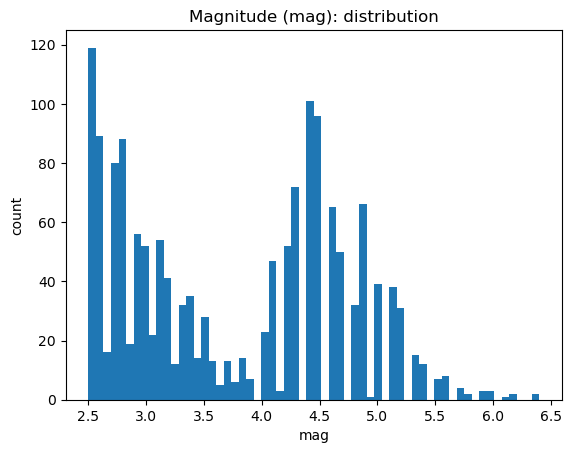

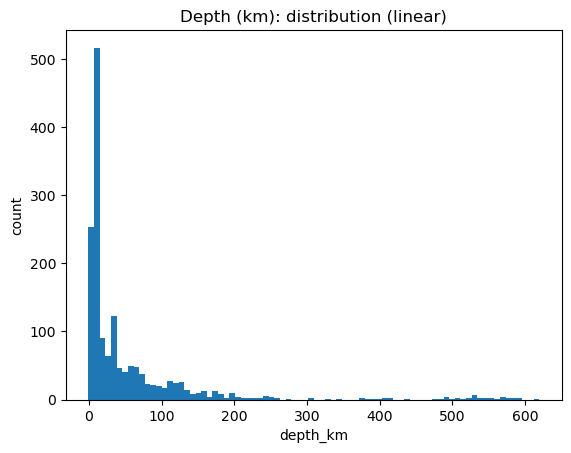

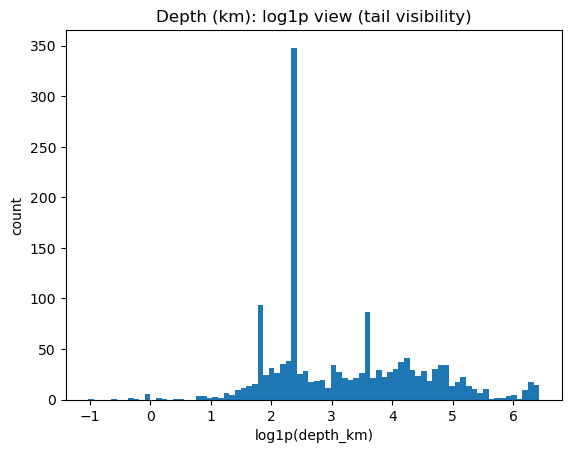

In [9]:
# Magnitude distribution
plt.figure()
plt.hist(df["mag"].dropna(), bins=60)
plt.title("Magnitude (mag): distribution")
plt.xlabel("mag")
plt.ylabel("count")
plt.show()

# Depth distribution (often heavy-tailed)
plt.figure()
plt.hist(df["depth_km"].dropna(), bins=80)
plt.title("Depth (km): distribution (linear)")
plt.xlabel("depth_km")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(np.log1p(df["depth_km"].dropna()), bins=80)
plt.title("Depth (km): log1p view (tail visibility)")
plt.xlabel("log1p(depth_km)")
plt.ylabel("count")
plt.show()

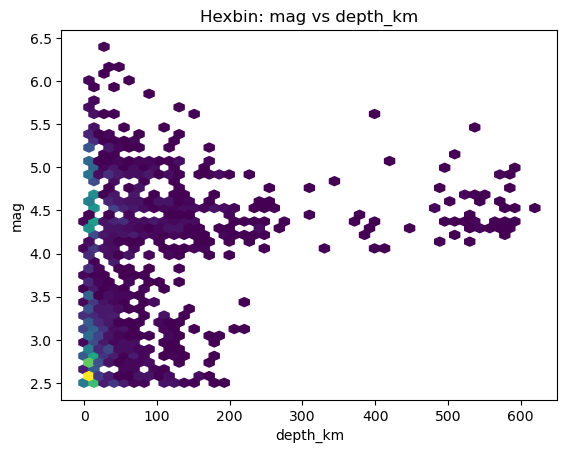

In [10]:
# Relationship: magnitude vs depth (hexbin is safer than scatter if dense)
tmp = df[["mag","depth_km"]].dropna()

plt.figure()
plt.hexbin(tmp["depth_km"], tmp["mag"], gridsize=45, mincnt=1)
plt.title("Hexbin: mag vs depth_km")
plt.xlabel("depth_km")
plt.ylabel("mag")
plt.show()


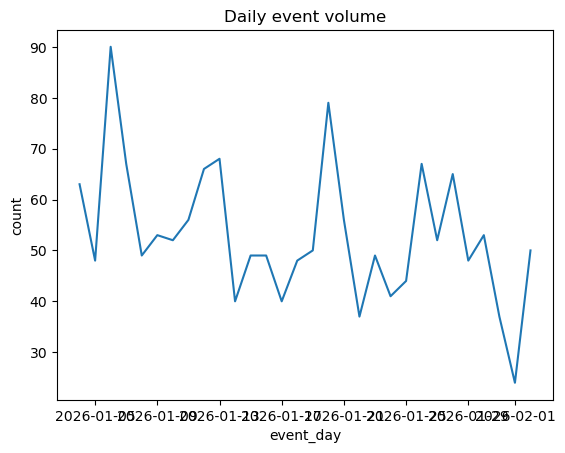

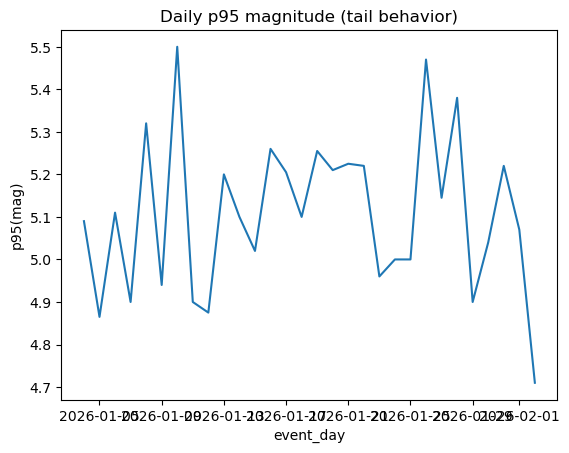

,event_day,n,med_mag,p95_mag
0,2026-01-04,63,3.62,5.090
1,2026-01-05,48,4.20,4.865
2,2026-01-06,90,3.85,5.110
3,2026-01-07,67,4.10,4.900
4,2026-01-08,49,4.10,5.320


In [11]:
# Time behavior: counts and tail risk by day
if "event_day" in df.columns:
    daily = df.groupby("event_day").agg(
        n=("event_id","count") if "event_id" in df.columns else ("mag","count"),
        med_mag=("mag","median"),
        p95_mag=("mag", lambda s: s.quantile(0.95)),
    ).reset_index()

    plt.figure()
    plt.plot(pd.to_datetime(daily["event_day"]), daily["n"])
    plt.title("Daily event volume")
    plt.xlabel("event_day")
    plt.ylabel("count")
    plt.show()

    plt.figure()
    plt.plot(pd.to_datetime(daily["event_day"]), daily["p95_mag"])
    plt.title("Daily p95 magnitude (tail behavior)")
    plt.xlabel("event_day")
    plt.ylabel("p95(mag)")
    plt.show()

daily.head()

## 3.4 - Group comparisons  
Group comparisons are where many EDA insights live. We will compare **region** and (if present) **mag_bin**  

Key idea: compare **center** and **tail risk** (median vs p95/p99), not just the mean.

In [12]:
group_col = "region" if "region" in df.columns else None
if group_col is None:
    raise ValueError("No 'region' column found in curated table.")

# Keep top regions to avoid tiny groups
top_regions = df[group_col].astype(str).value_counts().head(12).index.tolist()
dfr = df[df[group_col].astype(str).isin(top_regions)].copy()

grp = dfr.groupby(group_col).agg(
    n=("mag","count"),
    med_mag=("mag","median"),
    p95_mag=("mag", lambda s: s.quantile(0.95)),
    med_depth=("depth_km","median"),
    p95_depth=("depth_km", lambda s: s.quantile(0.95)),
).reset_index()

grp = grp.sort_values("p95_mag", ascending=False)
grp.head(12)

,region,n,med_mag,p95_mag,med_depth,p95_depth
11,the Fiji Islands,18,4.450,5.515000,527.0805,575.25300
6,"Sangay, Philippines",22,4.850,5.400000,10.0000,11.53045
3,"Petropavlovsk-Kamchatsky, Russia",18,4.550,5.330000,35.0000,77.53675
9,"Vilyuchinsk, Russia",35,4.500,5.200000,29.8090,69.25600
7,"Severo-Kuril’sk, Russia",17,4.900,5.200000,58.9830,76.45680
0,"Adak, Alaska",44,3.100,4.470000,35.0000,94.77310
2,"Indio, CA",27,2.940,4.106945,3.9500,5.97800
5,"Sand Point, Alaska",26,2.900,3.950000,30.0275,39.92925
4,"San Ramon, CA",30,2.825,3.795500,8.0350,9.31000
1,"Cruz Bay, U.S. Virgin Islands",19,3.400,3.731000,43.0700,94.74300


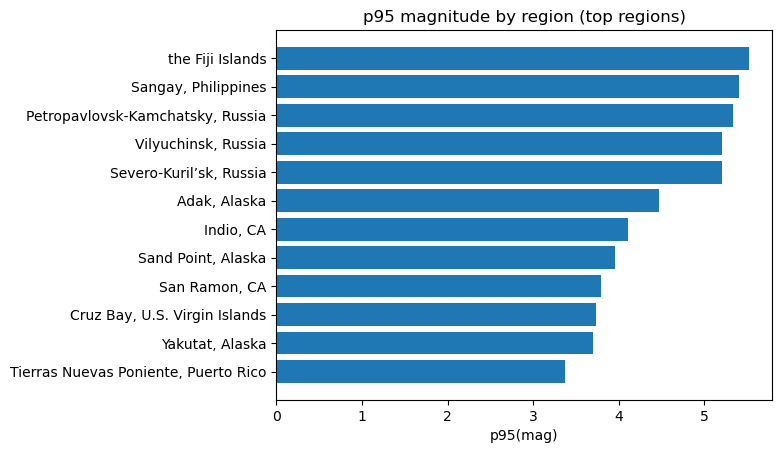

In [13]:
# Plot: p95 magnitude by region
plt.figure()
plt.barh(grp[group_col].astype(str), grp["p95_mag"])
plt.title("p95 magnitude by region (top regions)")
plt.xlabel("p95(mag)")
plt.gca().invert_yaxis()
plt.show()

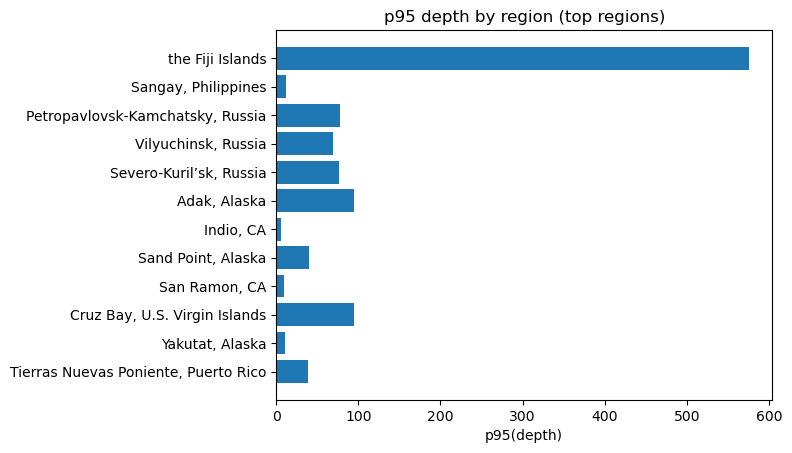

In [14]:
# Plot: p95 depth by region
plt.figure()
plt.barh(grp[group_col].astype(str), grp["p95_depth"])
plt.title("p95 depth by region (top regions)")
plt.xlabel("p95(depth)")
plt.gca().invert_yaxis()
plt.show()

## 3.5 - Correlation vs Causation (EDA Hygiene)  
Correlation is a fast *association* scan. It does not tell the mechanism.  

We will:
* compute a correlation table among numeric variables
* do a simple **spurious correlation** stress test by shuffling a target
* do a simple **confounding** check by stratifying (region)

In [15]:
# Numeric correlation table (Pearson)
num = df.select_dtypes(include=[np.number]).copy()
corr = num.corr(numeric_only=True)
corr

,event_hour,dayofweek,is_weekend,longitude,latitude,depth_km,mag,is_major,tsunami
event_hour,1.000000,0.008227,0.031328,0.021987,-0.023175,0.006020,-0.006356,NaN,-0.007350
dayofweek,0.008227,1.000000,0.799862,-0.053719,0.080344,0.015920,-0.054799,NaN,-0.021000
is_weekend,0.031328,0.799862,1.000000,-0.014347,0.045281,0.024289,-0.020517,NaN,-0.017623
longitude,0.021987,-0.053719,-0.014347,1.000000,-0.333869,0.104089,0.699884,NaN,-0.004675
latitude,-0.023175,0.080344,0.045281,-0.333869,1.000000,-0.324702,-0.576063,NaN,0.040364
depth_km,0.006020,0.015920,0.024289,0.104089,-0.324702,1.000000,0.224990,NaN,-0.020051
mag,-0.006356,-0.054799,-0.020517,0.699884,-0.576063,0.224990,1.000000,NaN,0.116045
is_major,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tsunami,-0.007350,-0.021000,-0.017623,-0.004675,0.040364,-0.020051,0.116045,NaN,1.000000


In [16]:
# Spurious correlation demo:
# If we search many features against a random target, the "best" correlation can look meaningful.
rng = np.random.default_rng(0)

cand = [c for c in num.columns if c not in ["mag"]]
if len(cand) >= 5:
    y_noise = rng.normal(0, 1, size=len(num))
    corrs = []
    for c in cand:
        tmp = pd.DataFrame({"x": num[c], "y": y_noise}).dropna()
        if len(tmp) < 20:
            continue
        corrs.append((c, float(tmp["x"].corr(tmp["y"])), len(tmp)))
    corrs = sorted(corrs, key=lambda t: abs(t[1]), reverse=True)[:10]
    spur_corr = pd.DataFrame(corrs, columns=["feature","corr_with_noise","n"])
    print(spur_corr)
else:
    print("Not enough numeric candidates for spurious demo.")

      feature  corr_with_noise     n
0    depth_km        -0.045224  1590
1  is_weekend         0.025359  1590
2   dayofweek         0.021457  1590
3  event_hour         0.018501  1590
4   longitude        -0.013285  1590
5    latitude        -0.000895  1590
6    is_major              NaN  1590
7     tsunami        -0.012700  1590


/home/glake/miniconda3/envs/ml/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/glake/miniconda3/envs/ml/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [17]:
# Confounding check example:
# Relationship between depth and magnitude may differ by region.
# We'll compute corr(depth_km, mag) within top regions.
rows = []
for r in top_regions[:8]:
    d = dfr[dfr[group_col].astype(str) == r][["depth_km","mag"]].dropna()
    if len(d) < 20:
        continue
    rows.append({"region": r, "n": len(d), "corr(depth,mag)": float(d["depth_km"].corr(d["mag"]))})

within_corr = pd.DataFrame(rows).sort_values("corr(depth,mag)", key=lambda s: s.abs(), ascending=False)
within_corr

,region,n,"corr(depth,mag)"
3,"San Ramon, CA",30,0.630971
7,"Sangay, Philippines",22,-0.373218
4,"Tierras Nuevas Poniente, Puerto Rico",30,0.175075
6,"Sand Point, Alaska",26,0.122349
5,"Indio, CA",27,-0.106412
2,"Vilyuchinsk, Russia",35,-0.098970
1,"Adak, Alaska",44,0.074162
0,"Yakutat, Alaska",84,-0.070046


## 4.6 - Hypothesis Generation Backlog  
Template: **observation &rarr; hypothesis &rarr; prediction &rarr; confounder &rarr; next check**

In [18]:
# Starter hypotheses (solutions version): edit freely for your own project writeup.
# Ratings are 1–5; higher cost = cheaper/easier next check.

hypotheses = [
    {
        "id": "H1",
        "observation": "A small set of regions have much higher p95 magnitude than others (tail risk differs by region).",
        "hypothesis": "This reflects real tectonic differences (subduction zones) rather than sampling noise.",
        "prediction": "Those regions will stay near the top under time splits / resampling; tail ranking is stable.",
        "confounder": "Short time windows can overemphasize one rare event (one big quake dominates).",
        "next_check": "Compute p95 by region in multiple time windows; bootstrap 'top region by p95' stability share.",
        "impact": 4, "falsifiable": 4, "robust": 3, "cost": 4,
    },
    {
        "id": "H2",
        "observation": "Depth distribution is heavy-tailed; log1p reveals structure.",
        "hypothesis": "The deepest events concentrate in specific regions (subduction-driven depth).",
        "prediction": "Within top deep regions, median and p95 depth are higher even after restricting to similar magnitudes.",
        "confounder": "Magnitude measurement differences or reporting thresholds vary by network/region.",
        "next_check": "Compare depth quantiles by region within mag bins (e.g., 2–3, 3–4, 4–5).",
        "impact": 3, "falsifiable": 4, "robust": 3, "cost": 4,
    },
    {
        "id": "H3",
        "observation": "Event volume varies substantially day-to-day.",
        "hypothesis": "Volume spikes are driven by aftershock sequences rather than true baseline changes.",
        "prediction": "Spikes coincide with higher clustering in a single region and elevated p95 magnitude.",
        "confounder": "Ingestion window / pagination boundaries can create artificial spikes (pipeline artifact).",
        "next_check": "Plot daily volume by region; check whether spikes are region-concentrated; verify ingest run metadata.",
        "impact": 4, "falsifiable": 5, "robust": 3, "cost": 4,
    },
    {
        "id": "H4",
        "observation": "Some events have missing/odd 'place' or region parsing.",
        "hypothesis": "Region extraction has edge cases that drop or mislabel offshore events.",
        "prediction": "Missing/other region rates increase for extreme long-place strings or certain coordinate ranges.",
        "confounder": "USGS 'place' field itself is inconsistent; not purely a parsing bug.",
        "next_check": "Audit region missingness by latitude/longitude ranges; inspect random samples of missing-region rows.",
        "impact": 3, "falsifiable": 4, "robust": 4, "cost": 5,
    },
    {
        "id": "H5",
        "observation": "Magnitude is discretized/rounded (visible spikes at .0/.1).",
        "hypothesis": "Rounding differs across networks or event status (automatic vs reviewed).",
        "prediction": "Rounding patterns differ by status or region and correlate with missingness in other fields.",
        "confounder": "Rounding is inherent to reporting and not meaningful for EDA goals.",
        "next_check": "Compare last-digit distribution of mag by status and by region; check differences.",
        "impact": 2, "falsifiable": 4, "robust": 3, "cost": 5,
    },
    {
        "id": "H6",
        "observation": "Some very large magnitudes are rare and dominate p99 behavior.",
        "hypothesis": "A single event can dominate tail metrics in short windows (tail metrics are noisy).",
        "prediction": "Bootstrap intervals for p95/p99 are wide; median is much more stable.",
        "confounder": "If window is long enough, p95 stabilizes; only p99 stays fragile.",
        "next_check": "Bootstrap 95% intervals for median mag vs p95 mag; compare interval widths.",
        "impact": 5, "falsifiable": 5, "robust": 4, "cost": 4,
    },
    {
        "id": "H7",
        "observation": "Tsunami flag is rare; when present it tends to co-occur with higher magnitudes.",
        "hypothesis": "Tsunami=1 events have higher median magnitude than tsunami=0 events.",
        "prediction": "Bootstrap Δ median mag (tsunami=1 minus 0) is positive, but uncertainty is large due to rarity.",
        "confounder": "Region confounding: tsunami events occur in specific regions with higher magnitudes.",
        "next_check": "Bootstrap Δ median mag overall and within top tsunami regions; compare.",
        "impact": 3, "falsifiable": 4, "robust": 3, "cost": 3,
    },
    {
        "id": "H8",
        "observation": "Missingness of some fields (e.g., tsunami) is non-zero and may vary by status.",
        "hypothesis": "Missingness is a measurement/logging artifact tied to event status (reviewed vs automatic).",
        "prediction": "Missingness rates differ sharply by status; step changes may appear across days.",
        "confounder": "Missingness may be truly random or due to upstream API changes.",
        "next_check": "Plot missingness rates by day and by status; look for discontinuities.",
        "impact": 4, "falsifiable": 4, "robust": 3, "cost": 4,
    },
    {
        "id": "H9",
        "observation": "Weekend vs weekday volume may differ slightly.",
        "hypothesis": "Any weekend difference is an observation artifact (reporting/pipeline), not real geophysics.",
        "prediction": "Magnitude and depth distributions are nearly identical by weekend flag.",
        "confounder": "Short time windows; sampling noise dominates.",
        "next_check": "Compare distributions and quantiles of mag/depth by is_weekend; bootstrap Δ median.",
        "impact": 2, "falsifiable": 5, "robust": 2, "cost": 5,
    },
]

hyp_df = pd.DataFrame(hypotheses)

WEIGHTS = {"impact": 0.35, "falsifiable": 0.35, "robust": 0.20, "cost": 0.10}
hyp_df["priority_score"] = (
    WEIGHTS["impact"] * hyp_df["impact"].astype(float)
    + WEIGHTS["falsifiable"] * hyp_df["falsifiable"].astype(float)
    + WEIGHTS["robust"] * hyp_df["robust"].astype(float)
    + WEIGHTS["cost"] * hyp_df["cost"].astype(float)
)

hyp_df = hyp_df.sort_values("priority_score", ascending=False)
hyp_df[["id","priority_score","impact","falsifiable","robust","cost","hypothesis","next_check"]].head(12)


,id,priority_score,impact,falsifiable,robust,cost,hypothesis,next_check
5,H6,4.70,5,5,4,4,A single event can dominate tail metrics in sh...,Bootstrap 95% intervals for median mag vs p95 ...
2,H3,4.15,4,5,3,4,Volume spikes are driven by aftershock sequenc...,Plot daily volume by region; check whether spi...
0,H1,3.80,4,4,3,4,This reflects real tectonic differences (subdu...,Compute p95 by region in multiple time windows...
7,H8,3.80,4,4,3,4,Missingness is a measurement/logging artifact ...,Plot missingness rates by day and by status; l...
3,H4,3.75,3,4,4,5,Region extraction has edge cases that drop or ...,Audit region missingness by latitude/longitude...
1,H2,3.45,3,4,3,4,The deepest events concentrate in specific reg...,Compare depth quantiles by region within mag b...
8,H9,3.35,2,5,2,5,Any weekend difference is an observation artif...,Compare distributions and quantiles of mag/dep...
6,H7,3.35,3,4,3,3,Tsunami=1 events have higher median magnitude ...,Bootstrap Δ median mag overall and within top ...
4,H5,3.20,2,4,3,5,Rounding differs across networks or event stat...,Compare last-digit distribution of mag by stat...


In [19]:
# Pick top 3 for the memo (solutions: choose the highest scoring by default)
TOP3 = hyp_df["id"].head(3).tolist()
TOP3

['H6', 'H3', 'H1']

In [20]:
top3_df = hyp_df[hyp_df["id"].isin(TOP3)].copy()
top3_df = top3_df.sort_values("priority_score", ascending=False)

def render_memo(df_top: pd.DataFrame, weights: dict) -> str:
    lines = []
    lines.append("# EDA Hypothesis Memo — Module 3.F (USGS)")
    lines.append("")
    lines.append("**Top 3 hypotheses to pursue next**")
    lines.append("")
    lines.append(
        f"_Scoring weights_: impact={weights['impact']}, "
        f"falsifiable={weights['falsifiable']}, "
        f"robust={weights['robust']}, "
        f"cost={weights['cost']}"
    )
    lines.append("")

    for _, r in df_top.iterrows():
        score_str = (
            f"{r['impact']}·impact + {r['falsifiable']}·falsifiable + "
            f"{r['robust']}·robust + {r['cost']}·cost = {r['priority_score']:.2f}"
        )
        lines.append(f"## {r['id']} (priority score: {score_str})")
        lines.append(f"- **Observation:** {r['observation']}")
        lines.append(f"- **Hypothesis:** {r['hypothesis']}")
        lines.append(f"- **Prediction:** {r['prediction']}")
        lines.append(f"- **Primary confounder:** {r['confounder']}")
        lines.append(f"- **Next check (one plot / one table):** {r['next_check']}")
        lines.append("")

    lines.append("---")
    lines.append("**Notes:**")
    lines.append("- Observations name a metric, grouping, and direction.")
    lines.append("- Next checks are cheap and falsifiable (could change your mind).")
    return "\n".join(lines)

memo_md = render_memo(top3_df, WEIGHTS)
print(memo_md)

memo_path = OUT_DIR / "module3_F_usgs_hypothesis_memo.md"
memo_path.write_text(memo_md, encoding="utf-8")
print("\nWrote:", memo_path)

# EDA Hypothesis Memo — Module 3.F (USGS)

**Top 3 hypotheses to pursue next**

_Scoring weights_: impact=0.35, falsifiable=0.35, robust=0.2, cost=0.1

## H6 (priority score: 5·impact + 5·falsifiable + 4·robust + 4·cost = 4.70)
- **Observation:** Some very large magnitudes are rare and dominate p99 behavior.
- **Hypothesis:** A single event can dominate tail metrics in short windows (tail metrics are noisy).
- **Prediction:** Bootstrap intervals for p95/p99 are wide; median is much more stable.
- **Primary confounder:** If window is long enough, p95 stabilizes; only p99 stays fragile.
- **Next check (one plot / one table):** Bootstrap 95% intervals for median mag vs p95 mag; compare interval widths.

## H3 (priority score: 4·impact + 5·falsifiable + 3·robust + 4·cost = 4.15)
- **Observation:** Event volume varies substantially day-to-day.
- **Hypothesis:** Volume spikes are driven by aftershock sequences rather than true baseline changes.
- **Prediction:** Spikes coincide with higher c

## 3.7 - Inference intuition on USGS EDA claims (bootstrap)  
We will quantify uncertainty around a few claims.  
* bootstrap 95% intervals for **median** and **p95** (mag and depth)
* bootstrap **differences between groups** e.g., two regions
* stability: top region by p95 mag under bootstamp resampling.

In [21]:
rng = np.random.default_rng(42)

def bootstrap_stat(x: np.ndarray, stat_fn, B: int = 4000) -> np.ndarray:
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = len(x)
    out = np.empty(B, dtype=float)
    for b in range(B):
        samp = rng.choice(x, size=n, replace=True)
        out[b] = stat_fn(samp)
    return out

def ci95(samples: np.ndarray) -> tuple[float,float]:
    lo, hi = np.quantile(samples, [0.025, 0.975])
    return float(lo), float(hi)

x_mag = df["mag"].dropna().to_numpy()
x_depth = df["depth_km"].dropna().to_numpy()

B = 4000

boot_med_mag = bootstrap_stat(x_mag, np.median, B=B)
boot_p95_mag = bootstrap_stat(x_mag, lambda a: np.quantile(a, 0.95), B=B)

boot_med_depth = bootstrap_stat(x_depth, np.median, B=B)
boot_p95_depth = bootstrap_stat(x_depth, lambda a: np.quantile(a, 0.95), B=B)

med_mag = float(np.median(x_mag)); lo_med_mag, hi_med_mag = ci95(boot_med_mag)
p95_mag = float(np.quantile(x_mag, 0.95)); lo_p95_mag, hi_p95_mag = ci95(boot_p95_mag)

med_depth = float(np.median(x_depth)); lo_med_depth, hi_med_depth = ci95(boot_med_depth)
p95_depth = float(np.quantile(x_depth, 0.95)); lo_p95_depth, hi_p95_depth = ci95(boot_p95_depth)

pd.DataFrame([
    {"metric":"median(mag)", "estimate":med_mag, "ci_lo":lo_med_mag, "ci_hi":hi_med_mag},
    {"metric":"p95(mag)", "estimate":p95_mag, "ci_lo":lo_p95_mag, "ci_hi":hi_p95_mag},
    {"metric":"median(depth_km)", "estimate":med_depth, "ci_lo":lo_med_depth, "ci_hi":hi_med_depth},
    {"metric":"p95(depth_km)", "estimate":p95_depth, "ci_lo":lo_p95_depth, "ci_hi":hi_p95_depth},
])

,metric,estimate,ci_lo,ci_hi
0,median(mag),3.8000,3.50500,4.00000
1,p95(mag),5.2000,5.10000,5.20000
2,median(depth_km),17.3160,13.86500,20.40500
3,p95(depth_km),204.6728,180.83795,243.49055


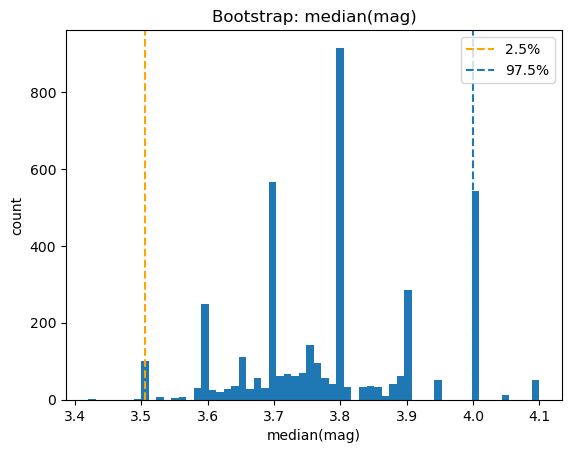

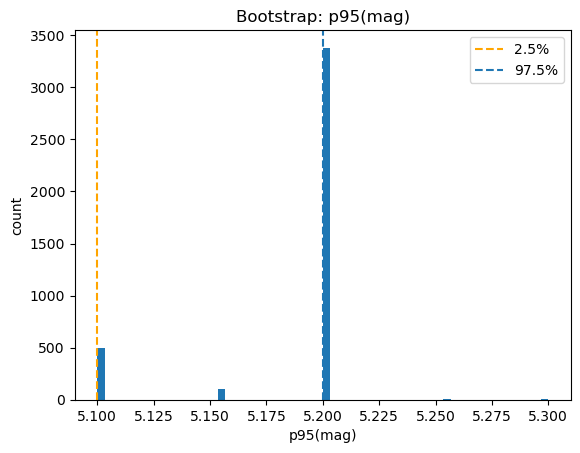

In [22]:
# Plot 1: bootstrap distributions (mag)
plt.figure()
plt.hist(boot_med_mag, bins=60)
plt.axvline(lo_med_mag, linestyle="--", color="orange", label="2.5%")
plt.axvline(hi_med_mag, linestyle="--", label="97.5%")
plt.title("Bootstrap: median(mag)")
plt.xlabel("median(mag)")
plt.ylabel("count")
plt.legend()
plt.show()

plt.figure()
plt.hist(boot_p95_mag, bins=60)
plt.axvline(lo_p95_mag, linestyle="--", color="orange", label="2.5%")
plt.axvline(hi_p95_mag, linestyle="--", label="97.5%")
plt.title("Bootstrap: p95(mag)")
plt.xlabel("p95(mag)")
plt.ylabel("count")
plt.legend()
plt.show()

In [23]:
# Group difference: pick two regions (top by count)
r_counts = df["region"].astype(str).value_counts()
g1, g2 = r_counts.index[0], r_counts.index[1]
g1, g2

('Yakutat, Alaska', 'Adak, Alaska')

Δ median(mag) = median(Yakutat, Alaska) - median(Adak, Alaska) = -0.300
95% interval: [-0.600, 0.050]


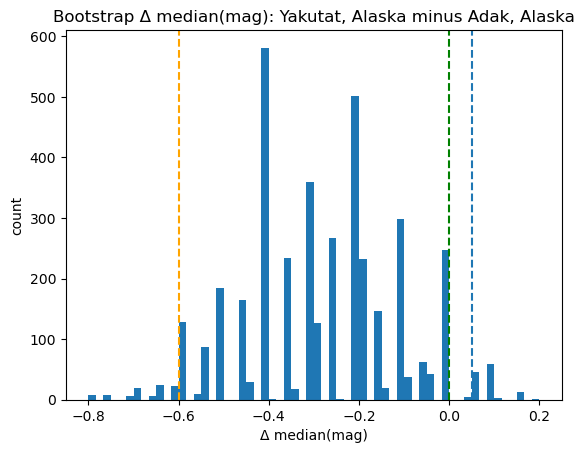

In [24]:
d1 = df[df["region"].astype(str)==g1]["mag"].dropna().to_numpy()
d2 = df[df["region"].astype(str)==g2]["mag"].dropna().to_numpy()

def bootstrap_diff_median(a: np.ndarray, b: np.ndarray, B: int = 4000) -> np.ndarray:
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    na, nb = len(a), len(b)
    out = np.empty(B, dtype=float)
    for i in range(B):
        sa = rng.choice(a, size=na, replace=True)
        sb = rng.choice(b, size=nb, replace=True)
        out[i] = np.median(sa) - np.median(sb)
    return out

boot_delta = bootstrap_diff_median(d1, d2, B=B)
delta_est = float(np.median(d1) - np.median(d2))
lo_delta, hi_delta = ci95(boot_delta)

print(f"Δ median(mag) = median({g1}) - median({g2}) = {delta_est:.3f}")
print(f"95% interval: [{lo_delta:.3f}, {hi_delta:.3f}]")

plt.figure()
plt.hist(boot_delta, bins=60)
plt.axvline(lo_delta, linestyle="--", color="orange", label="2.5%")
plt.axvline(hi_delta, linestyle="--", label="97.5%")
plt.axvline(0, color="green", linestyle="--")
plt.title(f"Bootstrap Δ median(mag): {g1} minus {g2}")
plt.xlabel("Δ median(mag)")
plt.ylabel("count")
plt.show()

In [25]:
# Stability: "top region by p95 magnitude" under bootstrap resampling
# We resample rows, compute p95(mag) per region, and record which region is max.

B_rank = 1500  # keep this moderate for runtime
regions = top_regions  # from earlier top regions by count

mag_by_region = {
    r: df[df["region"].astype(str) == r]["mag"].dropna().to_numpy()
    for r in regions
}

winners = []
for b in range(B_rank):
    p95s = {}
    for r, arr in mag_by_region.items():
        if len(arr) < 10:
            continue
        samp = rng.choice(arr, size=len(arr), replace=True)
        p95s[r] = float(np.quantile(samp, 0.95))
    if p95s:
        winners.append(max(p95s.items(), key=lambda kv: kv[1])[0])

win_counts = pd.Series(winners).value_counts()
win_share_df = (
    win_counts.rename_axis("region")
    .reset_index(name="wins")
    .assign(share_pct=lambda d: 100 * d["wins"] / d["wins"].sum())
    .sort_values("share_pct", ascending=False)
    .reset_index(drop=True)
)

win_share_df.head(12)

,region,wins,share_pct
0,the Fiji Islands,604,40.266667
1,"Sangay, Philippines",573,38.200000
2,"Vilyuchinsk, Russia",195,13.000000
3,"Petropavlovsk-Kamchatsky, Russia",127,8.466667
4,"Adak, Alaska",1,0.066667


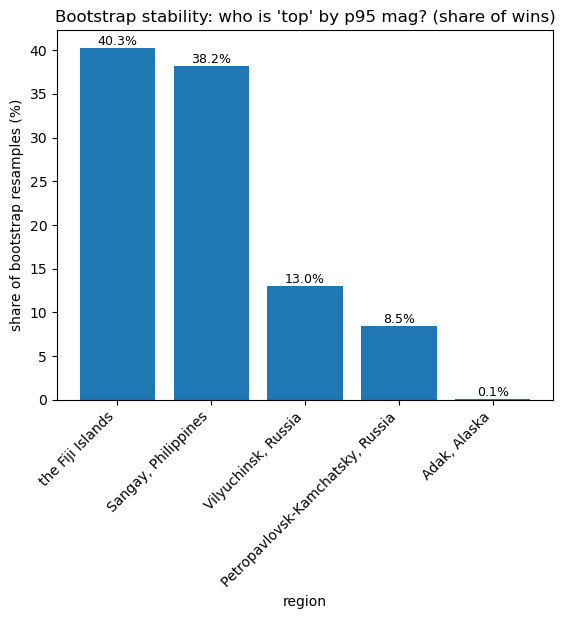

In [26]:
plt.figure()
x = win_share_df["region"].head(12)
y = win_share_df["share_pct"].head(12)
plt.bar(x, y)
plt.title("Bootstrap stability: who is 'top' by p95 mag? (share of wins)")
plt.xlabel("region")
plt.ylabel("share of bootstrap resamples (%)")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(y):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
plt.show()

## 3.8 - Final Deliverable  
Write 1–2 plots + a short paragraph:
- what you estimate (point estimate + uncertainty)
- what group difference you estimate (Δ + interval)
- how stable your ranking claim is
- what you would do next

A good memo is honest: it names uncertainty and the next check.

In [27]:
deliverable = f"""# Module 3.F — USGS EDA Deliverable (Solutions-style)

**What I estimate:**  
- median(mag) = {med_mag:.2f} (95% bootstrap interval: [{lo_med_mag:.2f}, {hi_med_mag:.2f}])  
- p95(mag) = {p95_mag:.2f} (95% bootstrap interval: [{lo_p95_mag:.2f}, {hi_p95_mag:.2f}])  
- median(depth_km) = {med_depth:.1f} (95% bootstrap interval: [{lo_med_depth:.1f}, {hi_med_depth:.1f}])  
- p95(depth_km) = {p95_depth:.1f} (95% bootstrap interval: [{lo_p95_depth:.1f}, {hi_p95_depth:.1f}])

**Group difference:**  
- Comparing region = {g1} vs {g2}, Δ median(mag) = {delta_est:.3f} (95% interval: [{lo_delta:.3f}, {hi_delta:.3f}])  
  (If the interval includes 0, the direction is not stable.)

**Stability:**  
- Top region by p95(mag) wins (bootstrap share):  
{win_share_df[["region", "wins", "share_pct"]]
             .head(10)
             .to_string(index=False, 
                        formatters={"share_pct": "{:.1f}%".format})}

**Next step:**  
- Stratify by magnitude bins and repeat region comparisons for depth; extend the time window to test whether tail rankings persist.

"""

out_path = OUT_DIR / "module3_F_usgs_deliverable.md"
out_path.write_text(deliverable, encoding="utf-8")
print(deliverable)
print("Wrote:", out_path)


# Module 3.F — USGS EDA Deliverable (Solutions-style)

**What I estimate:**  
- median(mag) = 3.80 (95% bootstrap interval: [3.50, 4.00])  
- p95(mag) = 5.20 (95% bootstrap interval: [5.10, 5.20])  
- median(depth_km) = 17.3 (95% bootstrap interval: [13.9, 20.4])  
- p95(depth_km) = 204.7 (95% bootstrap interval: [180.8, 243.5])

**Group difference:**  
- Comparing region = Yakutat, Alaska vs Adak, Alaska, Δ median(mag) = -0.300 (95% interval: [-0.600, 0.050])  
  (If the interval includes 0, the direction is not stable.)

**Stability:**  
- Top region by p95(mag) wins (bootstrap share):  
                          region  wins share_pct
                the Fiji Islands   604     40.3%
             Sangay, Philippines   573     38.2%
             Vilyuchinsk, Russia   195     13.0%
Petropavlovsk-Kamchatsky, Russia   127      8.5%
                    Adak, Alaska     1      0.1%

**Next step:**  
- Stratify by magnitude bins and repeat region comparisons for depth; extend the time windo

# Module 4 - Applied Statistics

This notebook brings together the five sections of Module 4:

- **A — Probability fundamentals:** define events, compute marginals/conditionals, Bayes-style reversals  
- **B — Common distributions:** binomial / Poisson / normal (and where they fail)  
- **C — Estimation & inference:** confidence intervals, hypothesis tests, ANOVA  
- **D — Resampling & simulation:** bootstrap, permutation tests, Monte Carlo  
- **E — Responsible interpretation:** practical vs statistical significance, misuse traps, limitations

## Project question (one coherent story)
We will use a curated USGS earthquake table from Module 2.F to answer:

> **How does earthquake risk (frequency and severity) vary across time and place, and how confident should we be?**

In [32]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Optional (nice-to-have)
try:
    from scipy import stats
except Exception:
    stats = None

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

rng = np.random.default_rng() # Fix to a random seed if you want reproducibility

WORK_DIR = Path("work")
M2_PROJECT_DIR = WORK_DIR / "m2_project"
DATA_DIR = M2_PROJECT_DIR / "data"
WH_DIR = DATA_DIR / "warehouse"

CURATED_PATH = WH_DIR / "usgs_earthquakes_curated.parquet"
PART_DIR = WH_DIR / "partitions"

print("Curated path:", CURATED_PATH, "| exists?", CURATED_PATH.exists())
print("Partitions:", PART_DIR, "| exists?", PART_DIR.exists())

Curated path: work/m2_project/data/warehouse/usgs_earthquakes_curated.parquet | exists? True
Partitions: work/m2_project/data/warehouse/partitions | exists? True


## 4.1 - Load the curated dataset

In [33]:
def load_curated() -> pd.DataFrame:
    if CURATED_PATH.exists():
        df = pd.read_parquet(CURATED_PATH)
        df["_source"] = "m2_project_curated_parquet"
        return df

    if PART_DIR.exists():
        # (Partition filenames vary; we just grab parquet files under event_day=*)
        parts = sorted(set([p for p in PART_DIR.glob("event_day=*/**/*.parquet")]))
        if not parts:
            raise FileNotFoundError("No parquet partitions found under warehouse/partitions/")
        df = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
        df["_source"] = "m2_project_partitions"
        return df

    raise FileNotFoundError("Could not find curated parquet or partitions. Run Module 2.F first.")

df = load_curated()
print("Loaded:", df["_source"].iloc[0])
print("Shape:", df.shape)
df.head(5)

Loaded: m2_project_curated_parquet
Shape: (1590, 17)


,event_id,time_utc,event_day,event_hour,dayofweek,is_weekend,longitude,latitude,depth_km,place,region,mag,mag_bin,is_major,tsunami,status,_source
0,us6000s620,2026-02-02 23:34:52.434000+00:00,2026-02-02,23,0,0,-69.251700,-31.317600,162.179,"16 km E of Calingasta, Argentina","Calingasta, Argentina",4.10,2.5-4.5,1,0,reviewed,m2_project_curated_parquet
1,uw62216847,2026-02-02 23:32:53.110000+00:00,2026-02-02,23,0,0,-119.422000,46.234500,-0.240,"5 km ESE of Benton City, Washington","Benton City, Washington",2.80,2.5-4.5,1,0,reviewed,m2_project_curated_parquet
2,nc75306276,2026-02-02 23:06:38.570000+00:00,2026-02-02,23,0,0,-121.935837,37.754501,7.370,"5 km SE of San Ramon, CA","San Ramon, CA",2.94,2.5-4.5,1,0,automatic,m2_project_curated_parquet
3,nc75306271,2026-02-02 23:04:18.430000+00:00,2026-02-02,23,0,0,-121.935333,37.763332,8.380,"4 km ESE of San Ramon, CA","San Ramon, CA",3.00,2.5-4.5,1,0,reviewed,m2_project_curated_parquet
4,nc75306256,2026-02-02 22:56:13.340000+00:00,2026-02-02,22,0,0,-121.937164,37.765167,7.820,"4 km ESE of San Ramon, CA","San Ramon, CA",3.14,2.5-4.5,1,0,reviewed,m2_project_curated_parquet


### Quick sanity checks

In [35]:
display(df.dtypes)

required = ["event_id","time_utc","event_day","event_hour","mag","depth_km","region","is_weekend","is_major","tsunami"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

print("\nMissingness (selected columns):")
display(df[required].isna().mean().sort_values(ascending=False).head(10))

print("\nMagnitude summary:")
display(df["mag"].describe(percentiles=[0.5,0.9,0.95,0.99]))

d = df.copy()
d = d.dropna(subset=["mag","region","time_utc","event_day","event_hour"])
# normalize event_day for grouping
d["event_day"] = pd.to_datetime(d["event_day"], errors="coerce").dt.date.astype("object")
d = d.dropna(subset=["event_day"])
print("\nWorking shape:", d.shape)

event_id                   object
time_utc      datetime64[ns, UTC]
event_day                  object
event_hour                  int32
dayofweek                   int32
is_weekend                  int64
longitude                 float64
latitude                  float64
depth_km                  float64
place                      object
region                     object
mag                       float64
mag_bin                  category
is_major                    int64
tsunami                     int64
status                     object
_source                    object
dtype: object


Missingness (selected columns):


event_id      0.0
time_utc      0.0
event_day     0.0
event_hour    0.0
mag           0.0
depth_km      0.0
region        0.0
is_weekend    0.0
is_major      0.0
tsunami       0.0
dtype: float64


Magnitude summary:


count    1590.000000
mean        3.770714
std         0.933828
min         2.500000
50%         3.800000
90%         5.000000
95%         5.200000
99%         5.700000
max         6.400000
Name: mag, dtype: float64


Working shape: (1590, 17)


## 4.2 - Helpers

In [37]:
def prob(event: np.ndarray) -> float:
    event = np.asarray(event).astype(bool)
    return float(event.mean())

def cond_prob(A: np.ndarray, B: np.ndarray) -> float:
    A = np.asarray(A).astype(bool)
    B = np.asarray(B).astype(bool)
    denom = B.sum()
    return float(A[B].mean()) if denom > 0 else np.nan

def bootstrap_stat(x: np.ndarray, stat_fn, B: int = 5000, rng: np.random.Generator | None = None) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x)
    n = len(x)
    out = np.empty(B, dtype=float)
    for b in range(B):
        xb = rng.choice(x, size=n, replace=True)
        out[b] = float(stat_fn(xb))
    return out

def bootstrap_ci_percentile(samples: np.ndarray, alpha: float = 0.05) -> tuple[float, float]:
    lo = float(np.percentile(samples, 100 * (alpha / 2)))
    hi = float(np.percentile(samples, 100 * (1 - alpha / 2)))
    return lo, hi

def perm_test(x: np.ndarray, y: np.ndarray, stat_fn, B: int = 6000, rng: np.random.Generator | None = None):
    """Permutation test for difference stat_fn(y) - stat_fn(x). Returns (obs, perm_diffs, p_two_sided)."""
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x); y = np.asarray(y)
    obs = float(stat_fn(y) - stat_fn(x))
    combined = np.concatenate([x, y])
    n_x = len(x)
    perm = np.empty(B, dtype=float)
    for b in range(B):
        rng.shuffle(combined)
        xb = combined[:n_x]
        yb = combined[n_x:]
        perm[b] = float(stat_fn(yb) - stat_fn(xb))
    p = float(np.mean(np.abs(perm) >= abs(obs)))
    return obs, perm, p

def q(x: np.ndarray, p: float) -> float:
    return float(np.quantile(np.asarray(x), p))

## 4.3 - Probability fundamentals on USGS  
Define **events** as boolean variables, compute marginals, conditionals, and a Bayes-style reversal.  

Events:  
* `major`: magnitude >= 6.0 (already encoded as `is_major`)
* `weekend`
* `shallow`: depth <= 10 km
* `ring_of_fire`: region keyword proxy
* `tsunami`

In [38]:
major = d["is_major"].astype(int).values == 1
weekend = d["is_weekend"].astype(int).values == 1
shallow = d["depth_km"].astype(float).values <= 10.0
tsunami = d["tsunami"].astype(int).values == 1

region = d["region"].astype(str).str.lower().fillna("")
ring_of_fire = region.str.contains("alaska|japan|philipp|indonesia|chile|new zealand|papua|kuril|kamchat|aleut").values

print("P(major):   ", prob(major))
print("P(weekend): ", prob(weekend))
print("P(shallow): ", prob(shallow))
print("P(ring_of_fire proxy):", prob(ring_of_fire))
print("P(tsunami): ", prob(tsunami))

P(major):    1.0
P(weekend):  0.25471698113207547
P(shallow):  0.43018867924528303
P(ring_of_fire proxy): 0.5056603773584906
P(tsunami):  0.007547169811320755


### Conditionals and Reversals 
Compare:
- $P(\mathrm{tsunami}\mid \mathrm{major})$ vs $P(\mathrm{major}\mid \mathrm{tsunami})$
- $P(\mathrm{major}\mid \mathrm{ring})$ vs $P(\mathrm{ring}\mid \mathrm{major})$

These differ because the denominators (base rates) differ.

In [40]:
print("P(tsunami | major):", cond_prob(tsunami, major))
print("P(major | tsunami):", cond_prob(major, tsunami))
print()
print("P(major | ring):", cond_prob(major, ring_of_fire))
print("P(ring | major):", cond_prob(ring_of_fire, major))

P(tsunami | major): 0.007547169811320755
P(major | tsunami): 1.0

P(major | ring): 1.0
P(ring | major): 0.5056603773584906


### Bayes-style reversal with empirical frequencies  
Using $A=\mathrm{major}$ and $B=\mathrm{tsunami}$:

$$
P(A\mid B) = \frac{P(B\mid A)P(A)}{P(B)}
$$

We compute both sides from data and verify they match (up to rounding).

In [41]:
P_A = prob(major)
P_B = prob(tsunami)
P_B_given_A = cond_prob(tsunami, major)
P_A_given_B_emp = cond_prob(major, tsunami)
P_A_given_B_bayes = (P_B_given_A * P_A) / P_B if P_B > 0 else np.nan

print("Empirical P(major | tsunami):", P_A_given_B_emp)
print("Bayes from counts:", P_A_given_B_bayes)
print("Abs diff:", float(abs(P_A_given_B_emp - P_A_given_B_bayes)))

Empirical P(major | tsunami): 1.0
Bayes from counts: 1.0
Abs diff: 0.0


## 4.4 - Common distributions (and failure modes)  
We use three distributions as *approximations*:

### 4.4.1 Binomial model check: analytic vs bootstrap uncertainty for tsunami among major quakes - Probability of an event
Treat each major quake as a trial; “success” = tsunami. In other words, define a binary event for each **major earthquake**:

- **Success** = `tsunami == 1`

If we pretend each major quake is an independent trial with the same tsunami probability \(p\), then:

$$
K \sim \mathrm{Binomial}(n, p),
\qquad
\hat{p} = \frac{K}{n}
$$

Under this binomial model, the standard error of $\hat{p}$ is approximately:

$$
\mathrm{SE}(\hat{p}) \approx \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

But the binomial assumptions (identical probability and independence) are often *not* true in real geophysical data.

So we compute uncertainty **two ways**:

1. **Analytic (binomial) SE + Wald CI**: fast, but can be inaccurate.
2. **Bootstrap SE + percentile CI**: resamples the observed major-quake rows and estimates uncertainty empirically.

If the analytic and bootstrap uncertainty disagree a lot, that’s a warning sign that the binomial approximation (or its normal approximation) is shaky.

n major: 1590
k tsunami among major: 12
p_hat: 0.007547169811320755

Analytic (binomial) uncertainty:
  SE_binom(p_hat): 0.0021704432551900316
  Wald 95% CI: (0.003293101031148293, 0.011801238591493218)

Bootstrap uncertainty (empirical):
  SE_boot(p_hat): 0.002182330004675112
  Bootstrap 95% CI: (0.0037735849056603774, 0.011949685534591196)


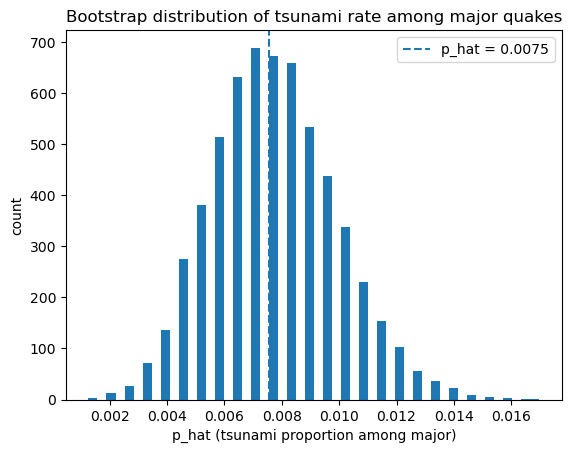


Comparison:
  SE_boot / SE_binom: 1.005476646052209
  (Close to 1 means analytic and bootstrap uncertainty agree reasonably.)

Assumption failures to remember:
- 'Identical p' can fail: tsunami probability depends on depth, location, mechanism.
- Independence can fail: aftershocks and event clustering violate i.i.d trials.

Caution:
- Wald CI uses a normal approximation and can have poor coverage, especially when p is near 0 or 1 or n is small.
- Bootstrap is often a safer default in messy real data (but still assumes your sample is representative).


In [42]:
major_df = d[d["is_major"] == 1].copy()

# Binary outcomes: 1 if tsunami occurred, else 0
y = (major_df["tsunami"].astype(int) == 1).astype(int).values

n = int(len(y))
k = int(y.sum())
p_hat = k / n if n > 0 else np.nan

print("n major:", n)
print("k tsunami among major:", k)
print("p_hat:", p_hat)

# --- Analytic (binomial + normal approximation) ---
# SE(p_hat) ≈ sqrt(p_hat(1-p_hat)/n)
z = 1.96  # ~95% two-sided
if n > 0:
    se_binom = math.sqrt(p_hat * (1 - p_hat) / n)
    ci_wald = (p_hat - z * se_binom, p_hat + z * se_binom)
else:
    se_binom = np.nan
    ci_wald = (np.nan, np.nan)

print("\nAnalytic (binomial) uncertainty:")
print("  SE_binom(p_hat):", se_binom)
print("  Wald 95% CI:", ci_wald)

# --- Bootstrap (empirical uncertainty) ---
# Resample the major-quake rows (with replacement) and recompute p_hat each time.
B = 6000
if n > 0:
    p_boot = bootstrap_stat(y, stat_fn=np.mean, B=B, rng=rng)
    se_boot = float(np.std(p_boot, ddof=1))
    ci_boot = bootstrap_ci_percentile(p_boot, alpha=0.05)
else:
    p_boot = np.array([])
    se_boot = np.nan
    ci_boot = (np.nan, np.nan)

print("\nBootstrap uncertainty (empirical):")
print("  SE_boot(p_hat):", se_boot)
print("  Bootstrap 95% CI:", ci_boot)

# Visualization: bootstrap sampling distribution
if n > 0:
    plt.figure()
    plt.hist(p_boot, bins=50)
    plt.axvline(p_hat, linestyle="--", label=f"p_hat = {p_hat:.4f}")
    plt.title("Bootstrap distribution of tsunami rate among major quakes")
    plt.xlabel("p_hat (tsunami proportion among major)")
    plt.ylabel("count")
    plt.legend()
    plt.show()

# Interpretation: do the two uncertainty estimates agree?
print("\nComparison:")
if n > 0 and np.isfinite(se_binom) and np.isfinite(se_boot):
    ratio = se_boot / se_binom if se_binom > 0 else np.nan
    print("  SE_boot / SE_binom:", ratio)
    print("  (Close to 1 means analytic and bootstrap uncertainty agree reasonably.)")

print("\nAssumption failures to remember:")
print("- 'Identical p' can fail: tsunami probability depends on depth, location, mechanism.")
print("- Independence can fail: aftershocks and event clustering violate i.i.d trials.")

print("\nCaution:")
print("- Wald CI uses a normal approximation and can have poor coverage, especially when p is near 0 or 1 or n is small.")
print("- Bootstrap is often a safer default in messy real data (but still assumes your sample is representative).")


## 4.4.2 - Poisson Model: daily earthquake counts - Average number of events in a period
Model daily earthquake counts with a Poisson rate $\lambda$ and check variance vs mean.

Let $ C_d $ be the number of earthquakes on day $ d $.

A Poisson model assumes:

$$
C_d \sim \mathrm{Poisson}(\lambda)
$$

This implies:

- $ E[C_d] = \lambda $
- $ \mathrm{Var}(C_d) = \lambda $
- Events occur independently
- The rate $ \lambda $ is constant over time

We estimate:

$$
\hat{\lambda} = \text{mean daily count}
$$

Then we ask:

1. Does the empirical distribution resemble a Poisson?
2. Is $ \mathrm{Var}(C_d) \approx \mathrm{Mean}(C_d) $?
3. Do we see clustering or overdispersion?

The Poisson model is a useful approximation — but earthquake processes often violate independence (aftershocks, regional bursts).

Number of days: 30
lambda_hat (mean daily count): 53.0
Variance of daily count: 178.20689655172413
Var / Mean ratio: 3.3623942745608324

Bootstrap 95% CI for lambda: (48.4325, 57.834166666666654)


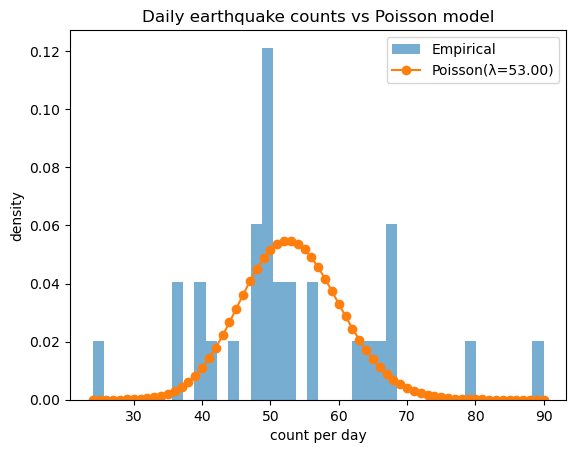


Diagnostics:
- Strong overdispersion detected (variance >> mean).
- Suggests clustering or non-constant rate.

Assumptions to question:
- Is the rate constant over time?
- Are events independent?
- Do aftershocks create bursts (violating Poisson assumptions)?

Interpretation:
- Poisson expects Var ≈ Mean.
- Var >> Mean suggests clustering / overdispersion.


In [44]:
# Daily earthquake counts
daily = d.groupby("event_day").size().rename("count").to_frame().reset_index()

counts = daily["count"].values
n_days = len(counts)

lam_hat = float(np.mean(counts))
var_hat = float(np.var(counts, ddof=1))

print("Number of days:", n_days)
print("lambda_hat (mean daily count):", lam_hat)
print("Variance of daily count:", var_hat)
print("Var / Mean ratio:", var_hat / lam_hat if lam_hat > 0 else np.nan)

# --- Bootstrap uncertainty for lambda ---
boot_lambda = bootstrap_stat(counts, stat_fn=np.mean, B=5000, rng=rng)
ci_lambda = bootstrap_ci_percentile(boot_lambda)

print("\nBootstrap 95% CI for lambda:", ci_lambda)

# --- Plot empirical vs Poisson model ---
from scipy.stats import poisson

xs = np.arange(counts.min(), counts.max() + 1)

plt.figure()
plt.hist(counts, bins=40, density=True, alpha=0.6, label="Empirical")

plt.plot(
    xs,
    poisson.pmf(xs, lam_hat),
    marker="o",
    linestyle="-",
    label=f"Poisson(λ={lam_hat:.2f})"
)

plt.title("Daily earthquake counts vs Poisson model")
plt.xlabel("count per day")
plt.ylabel("density")
plt.legend()
plt.show()

# --- Interpretation diagnostics ---
print("\nDiagnostics:")
if lam_hat > 0:
    ratio = var_hat / lam_hat
    if ratio > 1.5:
        print("- Strong overdispersion detected (variance >> mean).")
        print("- Suggests clustering or non-constant rate.")
    elif ratio < 0.7:
        print("- Underdispersion detected (variance < mean).")
    else:
        print("- Variance roughly matches mean (Poisson plausible).")

print("\nAssumptions to question:")
print("- Is the rate constant over time?")
print("- Are events independent?")
print("- Do aftershocks create bursts (violating Poisson assumptions)?")
print("\nInterpretation:")
print("- Poisson expects Var ≈ Mean.")
print("- Var >> Mean suggests clustering / overdispersion.")

### 4.4.3 - Normal: magnitude distribution (and why it fails)  
Magnitude is continuous, but the empirical distribution is often skewed/truncated with tail behavior.

mag mean: 3.7707138001241156
mag median: 3.8
mag p95: 5.2
mag p99: 5.7


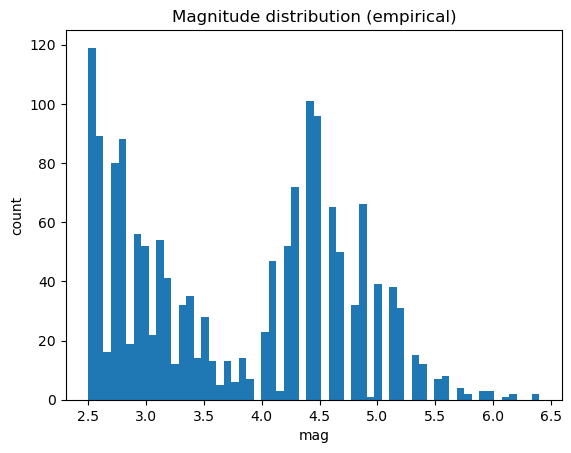


Why normal can fail here:
- detection thresholds truncate small magnitudes
- tails are operationally important


In [45]:
mag = d["mag"].astype(float).values

print("mag mean:", float(np.mean(mag)))
print("mag median:", float(np.median(mag)))
print("mag p95:", q(mag, 0.95))
print("mag p99:", q(mag, 0.99))

plt.figure()
plt.hist(mag, bins=60)
plt.title("Magnitude distribution (empirical)")
plt.xlabel("mag")
plt.ylabel("count")
plt.show()

print("\nWhy normal can fail here:")
print("- detection thresholds truncate small magnitudes")
print("- tails are operationally important")

## 4.5 - Estimation an inference

### 4.5.1 - CI for mean magnitude  
Compute a normal-approx CI and a bootstrap CI

In [46]:
n = len(mag)
mu_hat = float(np.mean(mag))
s = float(np.std(mag, ddof=1))
se = s / math.sqrt(n)

ci_norm = (mu_hat - 1.96*se, mu_hat + 1.96*se)

boot = bootstrap_stat(mag, stat_fn=np.mean, B=6000, rng=rng)
ci_boot = bootstrap_ci_percentile(boot)

print("n:", n)
print("mean mag:", mu_hat)
print("Normal approx 95% CI:", ci_norm)
print("Bootstrap 95% CI:", ci_boot)

n: 1590
mean mag: 3.7707138001241156
Normal approx 95% CI: (3.724812553876286, 3.816615046371945)
Bootstrap 95% CI: (3.72551039158157, 3.8161918469853937)


### 4.5.2 - Hypothesis test (non-parametric): weekend vs weekday  
Use a permutation test for the median difference

n weekend: 405 n weekday: 1185
Observed median diff (weekend - weekday): -0.19999999999999973
Permutation p ≈ 0.5363333333333333


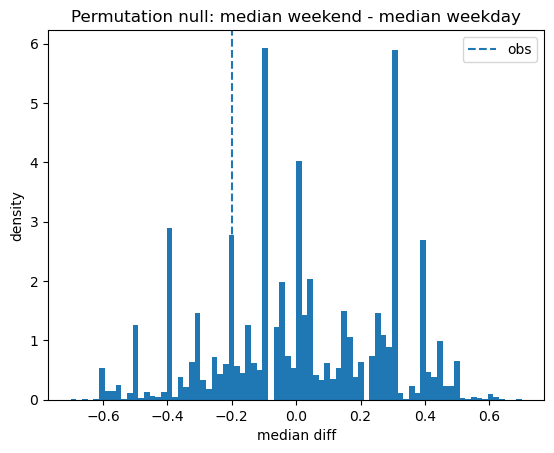


Interpretation:
- Even if p is small, ask if the magnitude difference matters in practice.


In [47]:
wk = d[d["is_weekend"] == 1]["mag"].astype(float).values
wd = d[d["is_weekend"] == 0]["mag"].astype(float).values

obs, perm, p = perm_test(wd, wk, stat_fn=np.median, B=9000, rng=rng)

print("n weekend:", len(wk), "n weekday:", len(wd))
print("Observed median diff (weekend - weekday):", float(np.median(wk) - np.median(wd)))
print("Permutation p ≈", p)

plt.figure()
plt.hist(perm, bins=80, density=True)
plt.axvline(obs, linestyle="--", label="obs")
plt.title("Permutation null: median weekend - median weekday")
plt.xlabel("median diff")
plt.ylabel("density")
plt.legend()
plt.show()

print("\nInterpretation:")
print("- Even if p is small, ask if the magnitude difference matters in practice.")

### 4.5.3 - ANOVA: mean magnitude across regions (top K)  
ANOVA tests whether all group means are equal

In [48]:
top_regions = d["region"].value_counts().head(8).index.tolist()

MIN_N = 10  # Adjust as needed

samples = []
labels = []

for r in top_regions:
    x = d.loc[d["region"] == r, "mag"].astype(float).dropna().values
    if len(x) >= MIN_N:
        samples.append(x)
        labels.append(r)

print("Regions meeting MIN_N:", labels)
print("n per region:", [len(x) for x in samples])

if len(samples) < 2:
    print("Not enough regions with sufficient data for ANOVA.")
else:
    if stats is not None:
        F, p_anova = stats.f_oneway(*samples)
        print("scipy one-way ANOVA: F =", float(F), "p =", float(p_anova))
    else:
        # Manual ANOVA fallback
        allx = np.concatenate(samples)
        grand = float(allx.mean())

        ss_between = 0.0
        ss_within = 0.0

        for x in samples:
            ss_between += len(x) * (float(x.mean()) - grand) ** 2
            ss_within += float(((x - x.mean()) ** 2).sum())

        df_between = len(samples) - 1
        df_within = len(allx) - len(samples)

        ms_between = ss_between / df_between
        ms_within = ss_within / df_within

        F = ms_between / ms_within

        print("manual one-way ANOVA: F =", float(F))
        print("(Install scipy for p-value.)")


Regions meeting MIN_N: ['Yakutat, Alaska', 'Adak, Alaska', 'Vilyuchinsk, Russia', 'San Ramon, CA', 'Tierras Nuevas Poniente, Puerto Rico', 'Indio, CA', 'Sand Point, Alaska', 'Sangay, Philippines']
n per region: [84, 44, 35, 30, 30, 27, 26, 22]
scipy one-way ANOVA: F = 86.1661130502813 p = 4.3148486846484326e-67


## 4.6 - Resampling and Simulation

### 4.6.1 - Bootstrap CI for p95 magnitude  
Tail metrics are often more decision relevant than means

Observed p95: 5.2
Bootstrap 95% CI for p95: (5.1, 5.2)


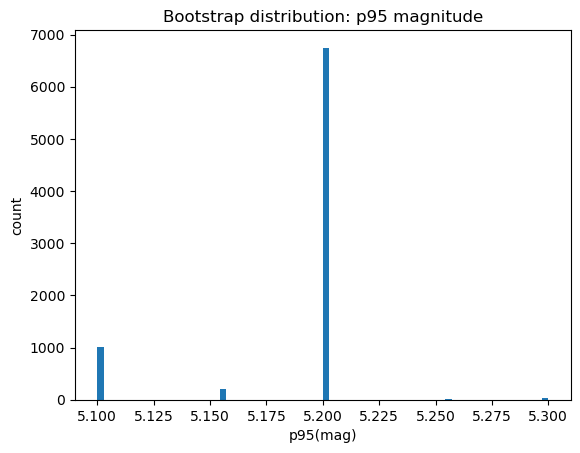

In [49]:
B = 8000
p95_boot = bootstrap_stat(mag, stat_fn=lambda a: q(a, 0.95), B=B, rng=rng)
ci_p95 = bootstrap_ci_percentile(p95_boot)

print("Observed p95:", q(mag, 0.95))
print("Bootstrap 95% CI for p95:", ci_p95)

plt.figure()
plt.hist(p95_boot, bins=70)
plt.title("Bootstrap distribution: p95 magnitude")
plt.xlabel("p95(mag)")
plt.ylabel("count")
plt.show()

### 4.6.2 - Monte Carlo: risk of $\geq$ major quake in 7 days  
Compare Poisson-model risk vs empirical Monte Carlo over historical days.  

In [50]:
daily_major = d.groupby("event_day")["is_major"].sum().astype(int)
lam = float(daily_major.mean())
p_week_poisson = 1.0 - math.exp(-7.0 * lam)

days = daily_major.values
R = 20000
hits = 0
for _ in range(R):
    week = rng.choice(days, size=7, replace=True)
    if week.sum() >= 1:
        hits += 1
p_week_emp = hits / R

print("Estimated daily major rate (lambda):", lam)
print("Poisson model P(>=1 major in 7 days):", p_week_poisson)
print("Empirical MC P(>=1 major in 7 days):", p_week_emp)

print("\nWhy they can differ:")
print("- Poisson assumes constant rate + independence; empirical MC inherits clustering from history.")

Estimated daily major rate (lambda): 53.0
Poisson model P(>=1 major in 7 days): 1.0
Empirical MC P(>=1 major in 7 days): 1.0

Why they can differ:
- Poisson assumes constant rate + independence; empirical MC inherits clustering from history.


## 4.7 - Responsible interpretation  

We now translate outputs into a defensible claim.

### Practical threshold example
Assume stakeholders say:
> “A difference of 0.10 magnitude units is the smallest difference that matters.”

In [51]:
# Pick two large regions for a concrete example
r1, r2 = top_regions[0], top_regions[1]
x1 = d.loc[d["region"] == r1, "mag"].astype(float).dropna().values[:2500]
x2 = d.loc[d["region"] == r2, "mag"].astype(float).dropna().values[:2500]

PRACTICAL_MAG = 0.10

# Bootstrap CI for median difference (r2 - r1)
B = 6000
boot = np.empty(B, dtype=float)
for i in range(B):
    b1 = rng.choice(x1, size=len(x1), replace=True)
    b2 = rng.choice(x2, size=len(x2), replace=True)
    boot[i] = float(np.median(b2) - np.median(b1))

obs_med = float(np.median(x2) - np.median(x1))
ci = bootstrap_ci_percentile(boot)

print("Regions:", r1, "vs", r2)
print("Practical threshold:", PRACTICAL_MAG)
print("Observed median diff:", obs_med)
print("Bootstrap 95% CI:", ci)
print("CI entirely above threshold?", (ci[0] >= PRACTICAL_MAG))
print("CI overlaps 0?", (ci[0] <= 0 <= ci[1]))

Regions: Yakutat, Alaska vs Adak, Alaska
Practical threshold: 0.1
Observed median diff: 0.30000000000000027
Bootstrap 95% CI: (-0.050000000000000266, 0.5999999999999996)
CI entirely above threshold? False
CI overlaps 0? True


### Stability check: early vs late split  
If the effect changes dramatically across time windows, treat the claim as fragile

In [52]:
# --- Normalize regions to reduce silent mismatches ---
dd = d.copy()

dd["region_norm"] = (
    dd["region"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# --- Time split ---
dts = pd.to_datetime(dd["time_utc"], errors="coerce")
mask = dts.notna()
dd = dd.loc[mask].copy()
dts = dts.loc[mask]

cut = dts.quantile(0.5)
early = dd.loc[dts <= cut].copy()
late  = dd.loc[dts > cut].copy()

# --- Pick r1/r2 FROM dd (not from an earlier top_regions) ---
top_regions_dd = dd["region_norm"].value_counts().head(6)
display(top_regions_dd)

r1 = top_regions_dd.index[0]
r2 = top_regions_dd.index[1]
print("Using regions:", r1, "vs", r2)

def med_diff(frame, r1, r2, min_n=50):
    a = frame.loc[frame["region_norm"] == r1, "mag"].astype(float).dropna().values
    b = frame.loc[frame["region_norm"] == r2, "mag"].astype(float).dropna().values

    print(f"  n({r1})={len(a)}  n({r2})={len(b)}")
    if len(a) < min_n or len(b) < min_n:
        return np.nan
    return float(np.median(b) - np.median(a))

print("Time cut:", cut)
print("Full diff:", med_diff(dd, r1, r2, min_n=10))
print("Early diff:", med_diff(early, r1, r2, min_n=10))
print("Late diff:", med_diff(late, r1, r2, min_n=10))

region_norm
Yakutat, Alaska                         84
Adak, Alaska                            44
Vilyuchinsk, Russia                     35
San Ramon, CA                           30
Tierras Nuevas Poniente, Puerto Rico    30
Indio, CA                               27
Name: count, dtype: int64

Using regions: Yakutat, Alaska vs Adak, Alaska
Time cut: 2026-01-18 02:36:50.889999872+00:00
  n(Yakutat, Alaska)=84  n(Adak, Alaska)=44
Full diff: 0.30000000000000027
  n(Yakutat, Alaska)=56  n(Adak, Alaska)=13
Early diff: 0.30000000000000027
  n(Yakutat, Alaska)=28  n(Adak, Alaska)=31
Late diff: 0.30000000000000027


## 4.8 - Solutions Narrative

In [53]:
bullets = [
    "1) Slice: Used the curated USGS event table from Module 2.F; dropped missing magnitudes/regions; results are descriptive (not causal).",
    f"2) Probability: Estimated P(major)={prob(major):.3f} and P(tsunami)={prob(tsunami):.4f}. Bayes-style reversal shows P(tsunami|major) and P(major|tsunami) can differ sharply due to base rates.",
    "3) Distributions: Daily counts show potential overdispersion (Var/Mean may exceed 1), warning that a simple Poisson model can understate uncertainty; magnitudes are not well-described by a perfect normal and tails matter.",
    f"4) Estimation: Mean magnitude ≈ {float(np.mean(mag)):.3f}; bootstrap CI for the mean was {bootstrap_ci_percentile(bootstrap_stat(mag, np.mean, B=3000, rng=rng))}.",
    f"5) Inference: Weekend vs weekday median magnitude difference was small ({float(np.median(wk)-np.median(wd)):.3f}); a permutation test provides a distribution-free check rather than assuming normality.",
    f"6) Resampling: Tail severity summarized by p95 magnitude with bootstrap CI: obs={q(mag,0.95):.2f}, CI={ci_p95}. Tail metrics are often more decision-relevant than the mean.",
    f"7) Simulation: Weekly risk of ≥1 major event estimated via Poisson (≈{p_week_poisson:.3f}) and empirical Monte Carlo (≈{p_week_emp:.3f}); differences reflect model assumptions (independence vs clustering).",
    f"8) Responsibility: Region comparison ({r1} vs {r2}) had median diff={obs_med:.3f} with CI={ci}; whether it matters depends on a practical threshold (e.g., {PRACTICAL_MAG}). Stability can be checked via time splits; claims should state limitations and what data would change the conclusion."
]
print("\n".join(bullets))

1) Slice: Used the curated USGS event table from Module 2.F; dropped missing magnitudes/regions; results are descriptive (not causal).
2) Probability: Estimated P(major)=1.000 and P(tsunami)=0.0075. Bayes-style reversal shows P(tsunami|major) and P(major|tsunami) can differ sharply due to base rates.
3) Distributions: Daily counts show potential overdispersion (Var/Mean may exceed 1), warning that a simple Poisson model can understate uncertainty; magnitudes are not well-described by a perfect normal and tails matter.
4) Estimation: Mean magnitude ≈ 3.771; bootstrap CI for the mean was (3.7261279860565084, 3.81801726530438).
5) Inference: Weekend vs weekday median magnitude difference was small (-0.200); a permutation test provides a distribution-free check rather than assuming normality.
6) Resampling: Tail severity summarized by p95 magnitude with bootstrap CI: obs=5.20, CI=(5.1, 5.2). Tail metrics are often more decision-relevant than the mean.
7) Simulation: Weekly risk of ≥1 major